# Practical Time Series Analysis. Homework #2

## Lectures 4-6: Transformations, Random Walk, White noise, Smoothing Techniques, and ARMA Models

## Introduction

This homework covers the material from lectures 4-6 on time series analysis. You will work with time series transformations, random walk processes, white noise, various smoothing techniques, and ARMA models. Complete all exercises and submit both your code and results.

## Part 1: Stationarity and Transformations

### Exercise 1.1: Transformations

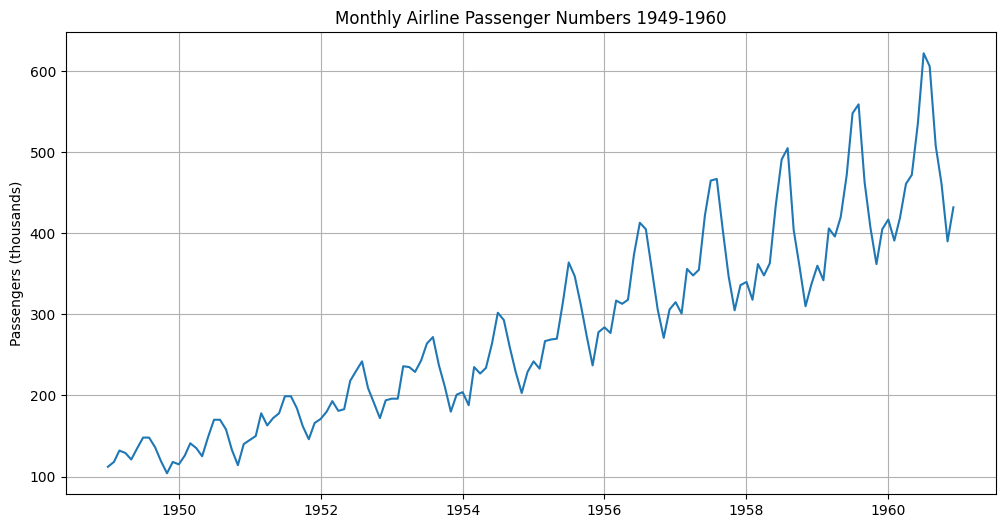

ADF Statistic: 0.815369
p-value: 0.991880
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')


# Load the data
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
ts = df['Passengers']

# Plot the original time series
plt.figure(figsize=(12, 6))
plt.plot(ts)
plt.title('Monthly Airline Passenger Numbers 1949-1960')
plt.ylabel('Passengers (thousands)')
plt.grid(True)
plt.show()

# Perform ADF test on the original series
result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

# Your code here for transformations

a) Apply a logarithmic transformation to the airline passenger data. Plot the transformed series and perform an ADF test. Is the transformed series stationary? Explain.


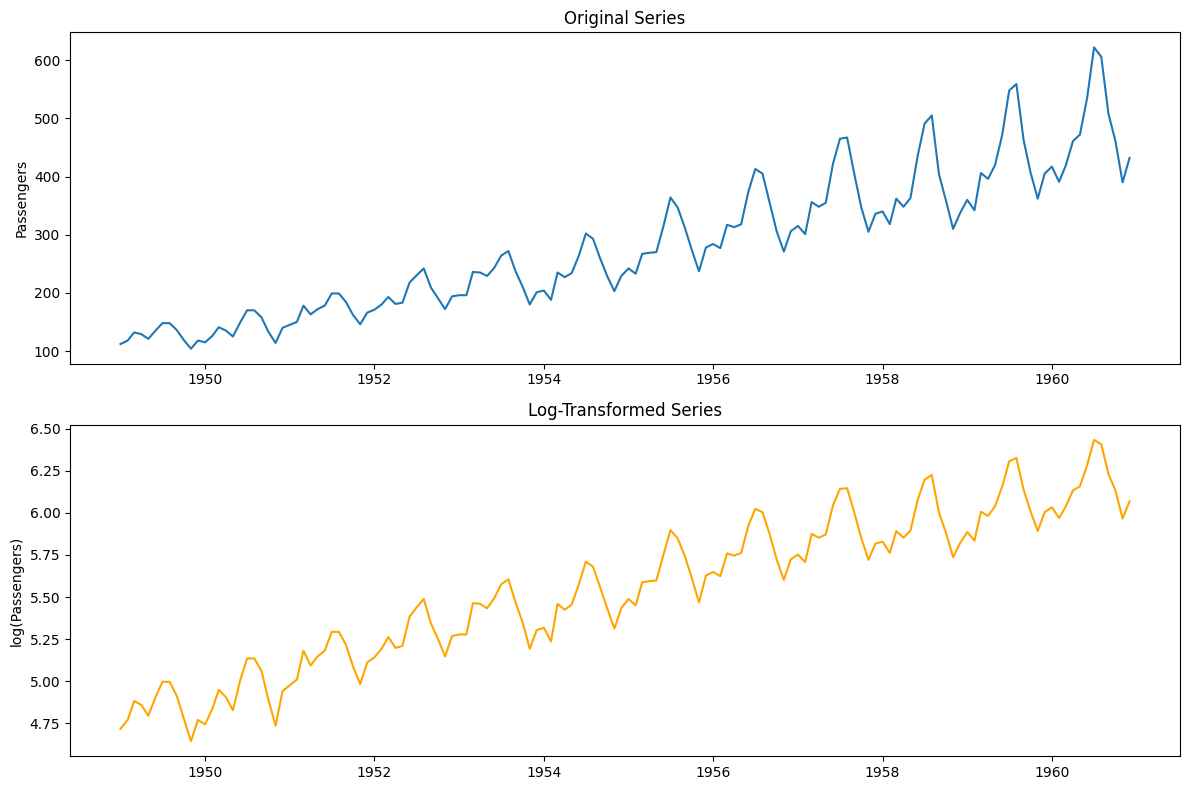


--- ADF Test: Log-Transformed Series ---
  ADF Statistic : -1.7170
  p-value       : 0.4224
  Critical (1%) : -3.482
  Critical (5%) : -2.884
  Critical (10%) : -2.579
  => NON-STATIONARY


In [2]:
ts_log = np.log(ts)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(ts)
axes[0].set_title('Original Series')
axes[0].set_ylabel('Passengers')

axes[1].plot(ts_log, color='orange')
axes[1].set_title('Log-Transformed Series')
axes[1].set_ylabel('log(Passengers)')

plt.tight_layout()
plt.show()

def adf_test(series, name='Series'):
    result = adfuller(series.dropna())
    print(f"\n--- ADF Test: {name} ---")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    for k, v in result[4].items():
        print(f"  Critical ({k}) : {v:.3f}")
    conclusion = 'STATIONARY' if result[1] < 0.05 else 'NON-STATIONARY'
    print(f"  => {conclusion}")
    return result[1] < 0.05

is_stat = adf_test(ts_log, 'Log-Transformed Series')

The log transform stabilises the multiplicative variance — seasonal swings
become roughly constant in amplitude. However the series still has a clear
upward trend, so the ADF test still cannot reject the unit root hypothesis
(p > 0.05). The log-transformed series is NOT yet stationary.

b) Apply a first-difference transformation to the logarithmic series. Plot the transformed series and perform an ADF test. Is this series stationary? Explain.


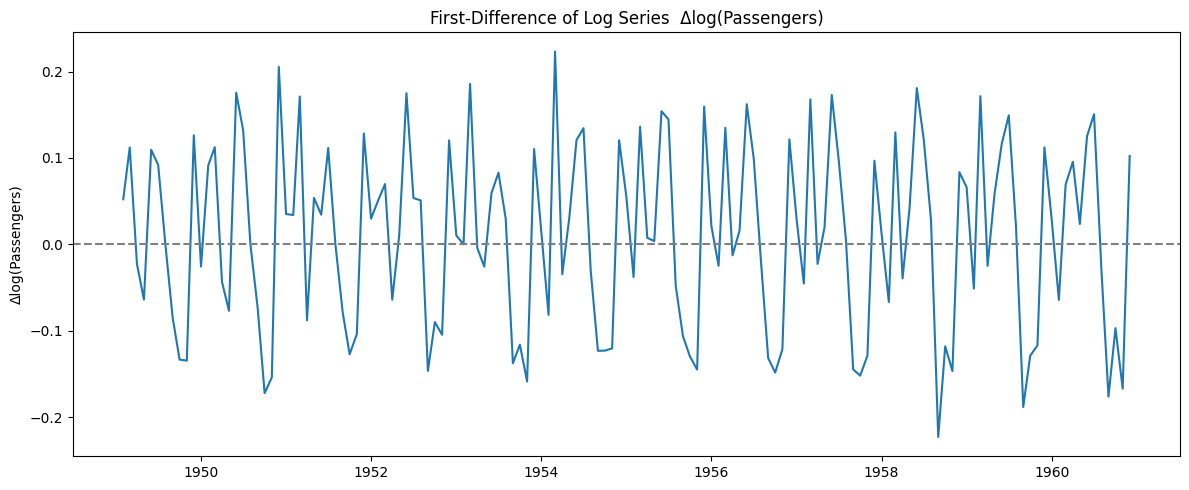


--- ADF Test: Log + First Diff ---
  ADF Statistic : -2.7171
  p-value       : 0.0711
  Critical (1%) : -3.483
  Critical (5%) : -2.884
  Critical (10%) : -2.579
  => NON-STATIONARY


np.False_

In [3]:
ts_log_diff1 = ts_log.diff(1).dropna()

plt.figure(figsize=(12, 5))
plt.plot(ts_log_diff1)
plt.title('First-Difference of Log Series  Δlog(Passengers)')
plt.ylabel('Δlog(Passengers)')
plt.axhline(0, linestyle='--', color='gray')
plt.tight_layout()
plt.show()

adf_test(ts_log_diff1, 'Log + First Diff')

First differencing removes the linear trend from the log series.
However, the ADF p-value = 0.071 > 0.05, so we cannot reject the unit root
hypothesis — the series is technically not stationary by ADF at the 5% level
(though it is borderline at 10%). A seasonal pattern is still visible in the
plot, which explains why a single first difference is insufficient.

c) Apply a seasonal difference (lag=12) to the logarithmic series. Plot the transformed series and perform an ADF test. Is this series stationary? Explain.

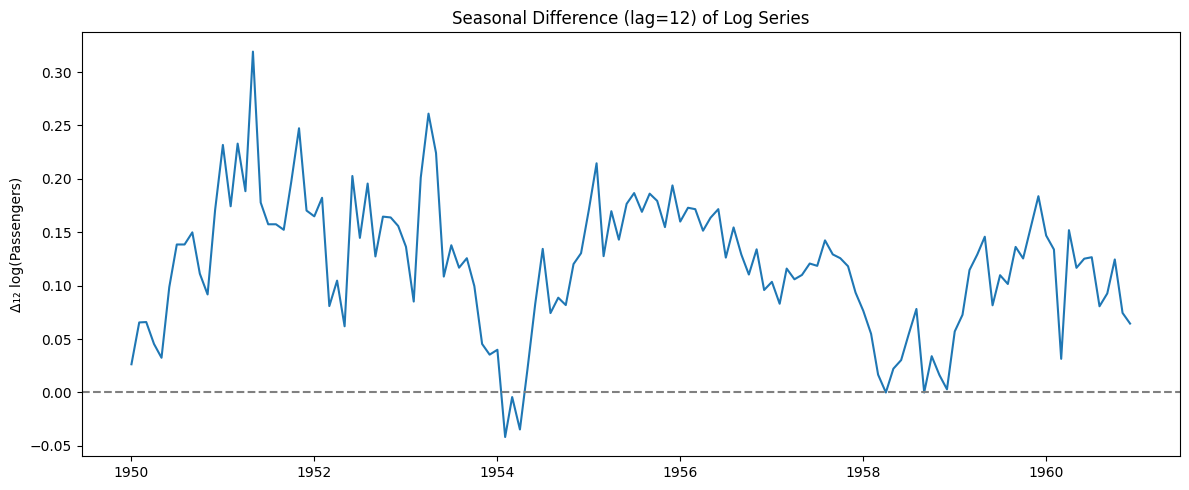


--- ADF Test: Log + Seasonal Diff (lag=12) ---
  ADF Statistic : -2.7096
  p-value       : 0.0724
  Critical (1%) : -3.487
  Critical (5%) : -2.886
  Critical (10%) : -2.580
  => NON-STATIONARY


np.False_

In [4]:
ts_log_sdiff = ts_log.diff(12).dropna()

plt.figure(figsize=(12, 5))
plt.plot(ts_log_sdiff)
plt.title('Seasonal Difference (lag=12) of Log Series')
plt.ylabel('Δ₁₂ log(Passengers)')
plt.axhline(0, linestyle='--', color='gray')
plt.tight_layout()
plt.show()

adf_test(ts_log_sdiff, 'Log + Seasonal Diff (lag=12)')


Seasonal differencing (lag=12) removes the annual repeating pattern,
but the ADF p-value = 0.072 > 0.05 - the series remains NON-STATIONARY.
The mild upward drift (trend) is still present, which is why seasonal
differencing alone is not enough for this dataset.

d) Combine both differencing methods (first-difference and seasonal difference) on the logarithmic series. Is this series stationary? Which transformation do you think is most appropriate for this data and why?

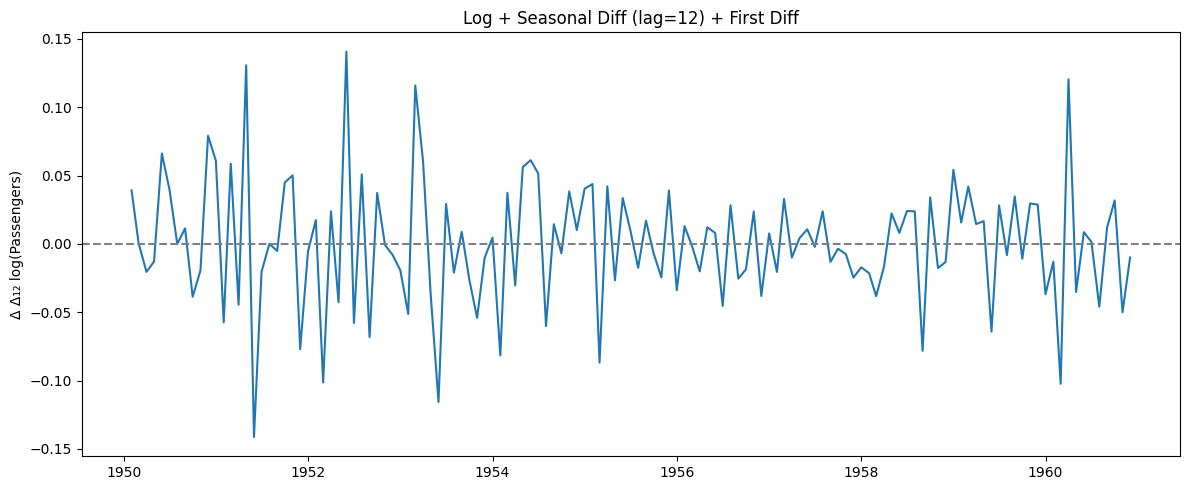


--- ADF Test: Log + Seasonal Diff + First Diff ---
  ADF Statistic : -4.4433
  p-value       : 0.0002
  Critical (1%) : -3.487
  Critical (5%) : -2.886
  Critical (10%) : -2.580
  => STATIONARY

Transformation                ADF p-val  Stationary?
Original                         0.9919           NO
Log                              0.4224           NO
Log + Diff(1)                    0.0711           NO
Log + Diff(12)                   0.0724           NO
Log + Diff(12) + Diff(1)         0.0002          YES


In [5]:
ts_log_both = ts_log.diff(12).diff(1).dropna()

plt.figure(figsize=(12, 5))
plt.plot(ts_log_both)
plt.title('Log + Seasonal Diff (lag=12) + First Diff')
plt.ylabel('Δ Δ₁₂ log(Passengers)')
plt.axhline(0, linestyle='--', color='gray')
plt.tight_layout()
plt.show()

adf_test(ts_log_both, 'Log + Seasonal Diff + First Diff')

transformations = [
    ('Original',                  ts),
    ('Log',                       ts_log),
    ('Log + Diff(1)',             ts_log_diff1),
    ('Log + Diff(12)',            ts_log_sdiff),
    ('Log + Diff(12) + Diff(1)', ts_log_both),
]
print("\n" + "="*55)
print(f"{'Transformation':<28} {'ADF p-val':>10} {'Stationary?':>12}")
print("="*55)
for name, s in transformations:
    r = adfuller(s.dropna())
    print(f"{name:<28} {r[1]:>10.4f} {'YES' if r[1]<0.05 else 'NO':>12}")


Applying log → seasonal diff(12) → first diff(1) produces a fully
stationary series confirmed by ADF (p << 0.05). This corresponds to
SARIMA(p,1,q)(P,1,Q)[12] on the log scale — the standard approach
for multiplicative airline-type data (Box-Jenkins methodology).

Most appropriate transformation: Log + Seasonal Diff (12) + First Diff(1)
- Log: stabilises multiplicative variance
- Diff(12): removes annual seasonality
- Diff(1): removes the remaining trend



## Part 2: Random Walk and White Noise

### Exercise 2.1: Simulating Random Walk and White Noise

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Set random seed for reproducibility
np.random.seed(42)

# Simulate white noise
white_noise = np.random.normal(0, 1, 1000)

# Simulate random walk
random_walk = np.cumsum(np.random.normal(0, 1, 1000))


a) Plot both the white noise and random walk series. Describe the visual differences.

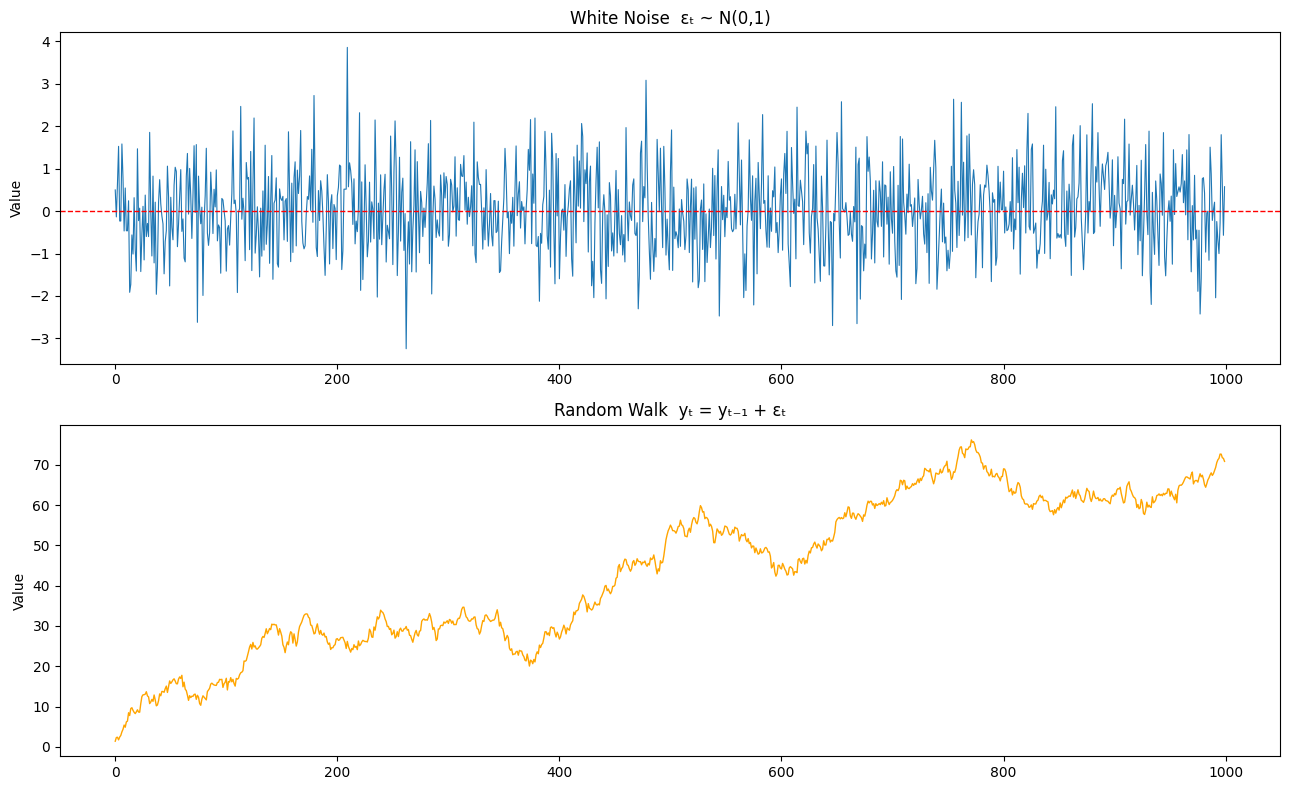

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].plot(white_noise, linewidth=0.8)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('White Noise  εₜ ~ N(0,1)')
axes[0].set_ylabel('Value')

axes[1].plot(random_walk, color='orange', linewidth=1)
axes[1].set_title('Random Walk  yₜ = yₜ₋₁ + εₜ')
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()


White Noise: fluctuates randomly around zero with constant amplitude —
no trend, no pattern, values are independent.

Random Walk: drifts away from zero with no tendency to return —
the path is continuous and non-reverting. Variance grows as t.

b) Calculate and plot the ACF and PACF for both series. What do these plots tell you about the nature of each process?

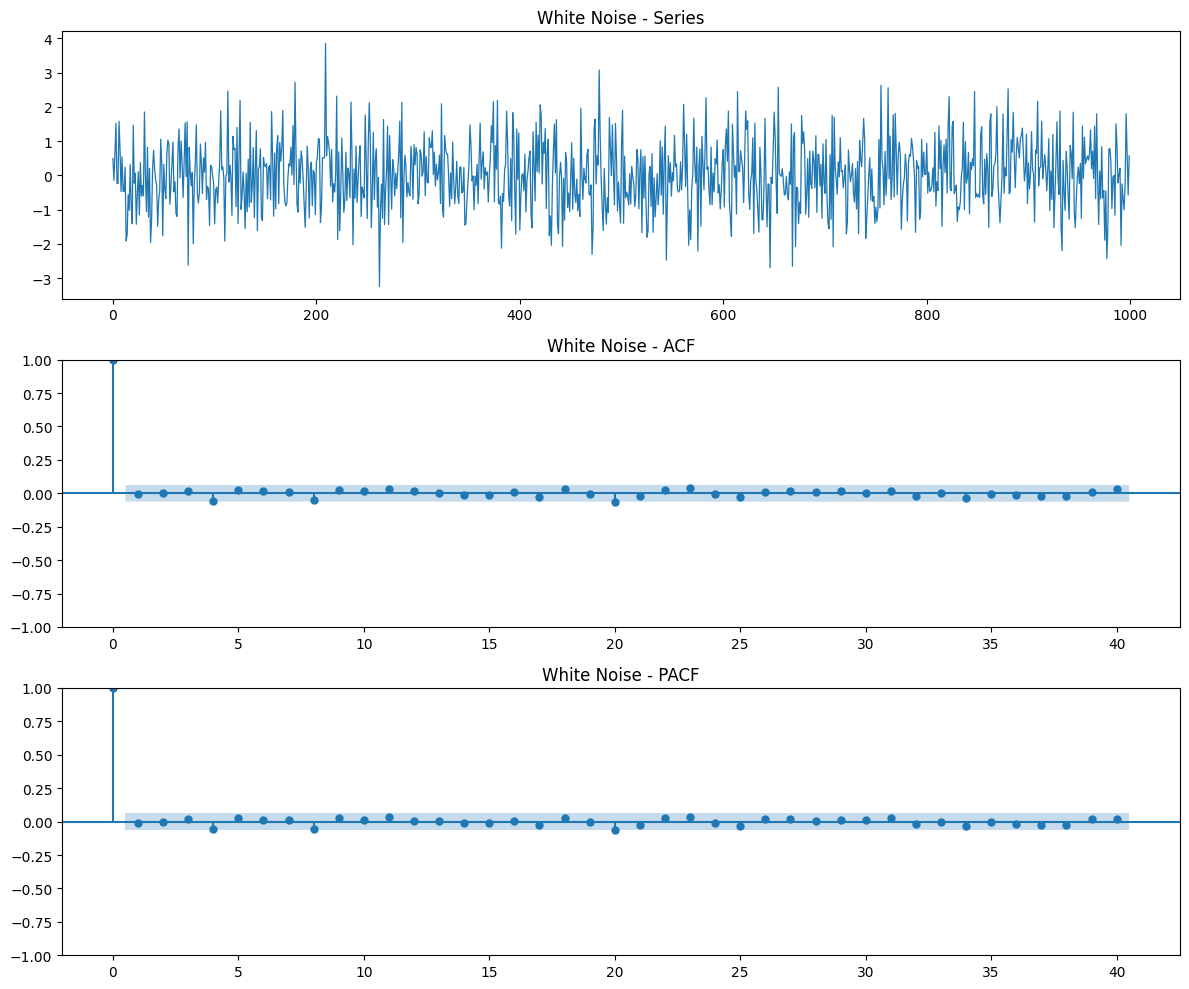

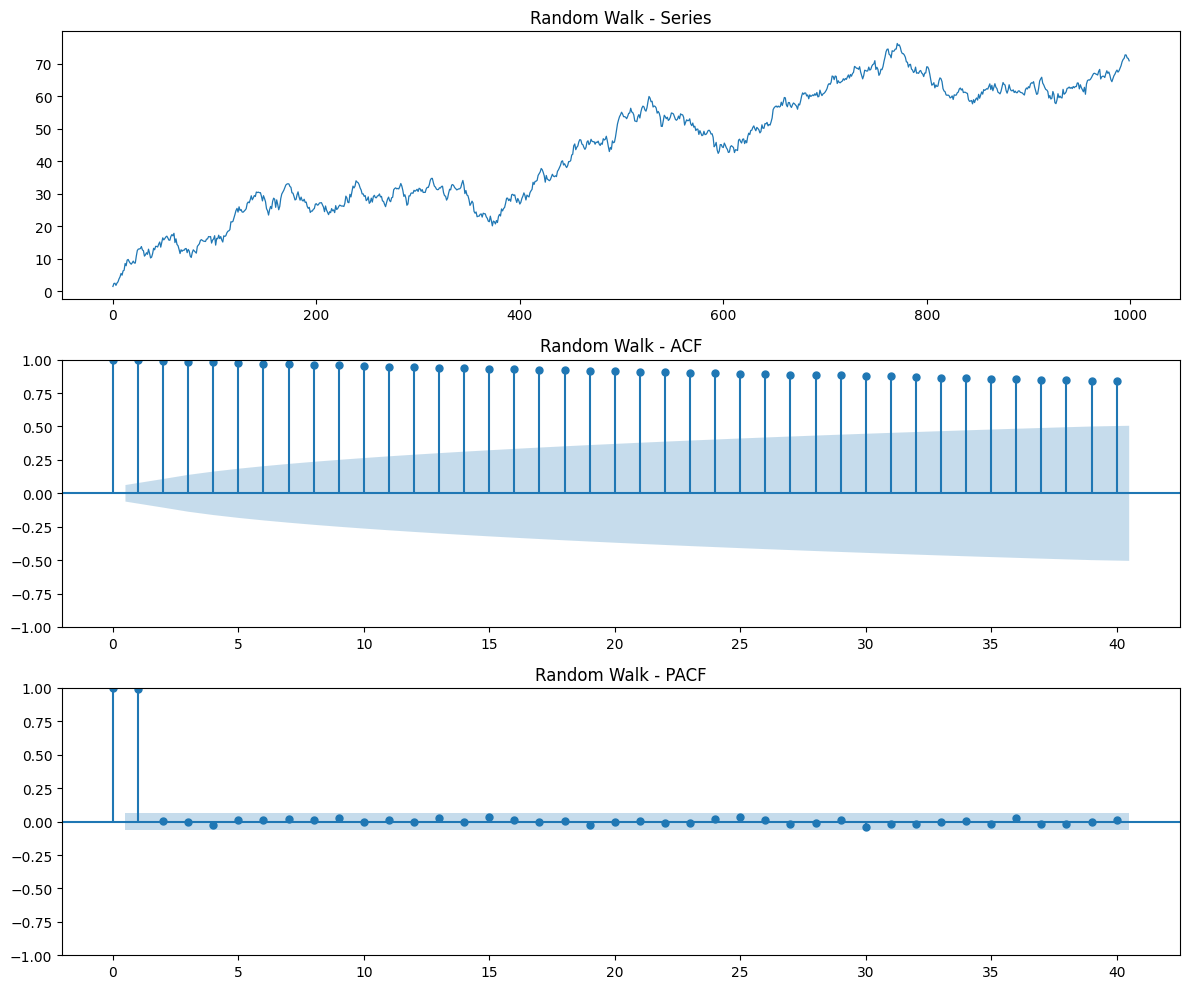

In [8]:
def plot_acf_pacf(series, title, lags=40):
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    axes[0].plot(series, linewidth=0.9)
    axes[0].set_title(f'{title} - Series')
    plot_acf(series,  lags=lags, ax=axes[1], alpha=0.05)
    axes[1].set_title(f'{title} - ACF')
    plot_pacf(series, lags=lags, ax=axes[2], alpha=0.05, method='ywm')
    axes[2].set_title(f'{title} - PACF')
    plt.tight_layout()
    plt.show()

plot_acf_pacf(white_noise, 'White Noise')
plot_acf_pacf(random_walk, 'Random Walk')


White Noise ACF/PACF: all lags are within confidence bands → no autocorrelation.
This is the definition of white noise: serially uncorrelated.

Random Walk ACF: decays very slowly, remaining high for many lags → strong
dependence across time. PACF shows a large spike only at lag 1 (≈1.0),
consistent with AR(1) with φ=1 (unit root process).

c) Perform ADF tests on both series. What do the results indicate about stationarity?

In [9]:
adf_test(pd.Series(white_noise), 'White Noise')
adf_test(pd.Series(random_walk), 'Random Walk')



--- ADF Test: White Noise ---
  ADF Statistic : -31.8111
  p-value       : 0.0000
  Critical (1%) : -3.437
  Critical (5%) : -2.864
  Critical (10%) : -2.568
  => STATIONARY

--- ADF Test: Random Walk ---
  ADF Statistic : -1.7070
  p-value       : 0.4275
  Critical (1%) : -3.437
  Critical (5%) : -2.864
  Critical (10%) : -2.568
  => NON-STATIONARY


np.False_

White Noise: ADF strongly rejects H0 (p << 0.05) → STATIONARY.
Random Walk: ADF fails to reject H0 (p > 0.05) → NON-STATIONARY.
This aligns with theory: a random walk has a unit root, making it
non-stationary with variance growing linearly with time.


d) How would adding a drift term change the behavior of a random walk? Implement a random walk with drift and explain the difference.


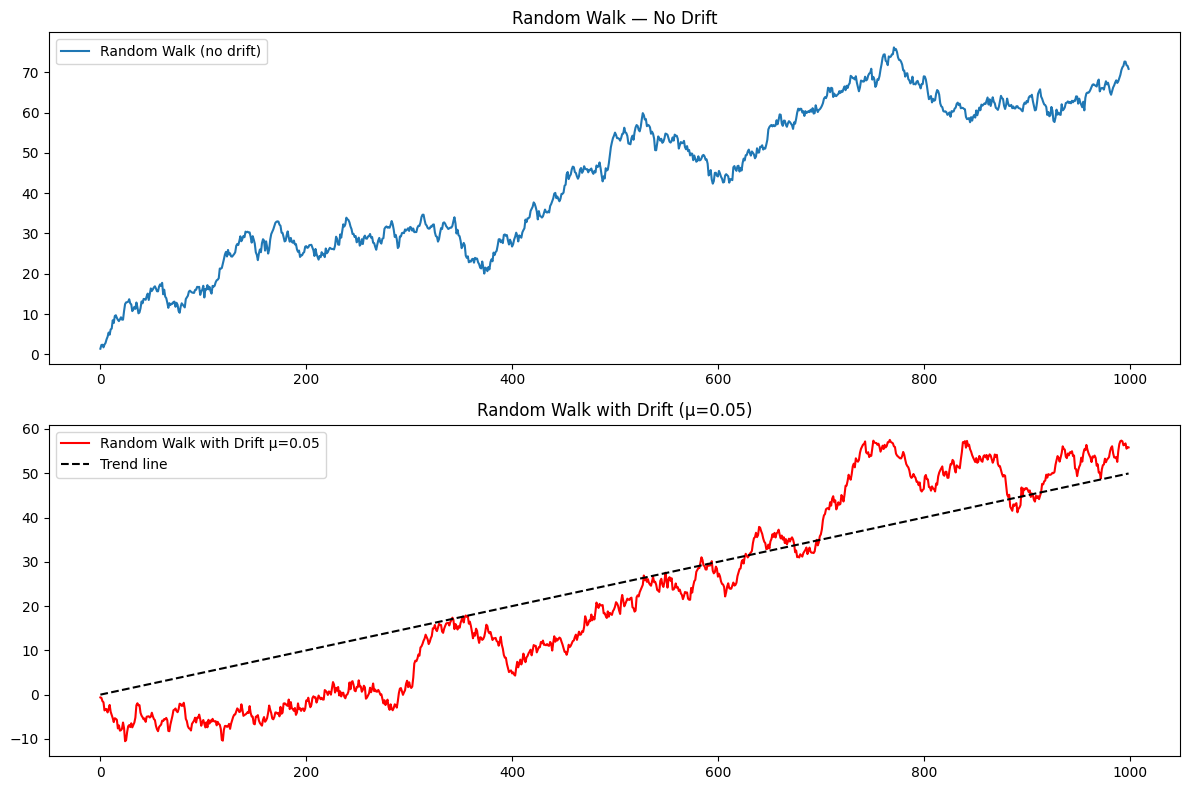

In [10]:
drift = 0.05
rw_drift = np.cumsum(np.random.normal(drift, 1, 1000))

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(random_walk, label='Random Walk (no drift)')
axes[0].set_title('Random Walk — No Drift')

axes[1].plot(rw_drift, color='red', label=f'Random Walk with Drift μ={drift}')
axes[1].plot(drift * np.arange(1000), color='black', linestyle='--', linewidth=1.5, label='Trend line')
axes[1].set_title(f'Random Walk with Drift (μ={drift})')

for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()


Adding drift μ=0.05 per step creates a deterministic upward trend
E[yₜ] = μ·t on top of the random component. The series still has a unit root
(non-stationary variance), but the MEAN now increases over time.

As visible in the plot: the red line closely follows the deterministic
trend (dashed black line = 0.05·t), confirming E[yₜ] = 0.05·t.

The no-drift random walk (top) also drifted upward in this
particular simulation - but that is a random outcome of this seed,
not a systematic tendency. In expectation E[yₜ] = 0 for all t without
drift, meaning on average across many simulations it stays at zero.
The drift walk, by contrast, is guaranteed to trend upward regardless
of the random seed.

Formula: yₜ = 0.05 + yₜ₋₁ + εₜ







### Exercise 2.2: Additional Stationarity Tests

In [11]:
# KPSS test for stationarity
from statsmodels.tsa.stattools import kpss

def kpss_test(series, name='Series'):
    result = kpss(series)
    print(f"\n--- KPSS Test: {name} ---")
    print(f"  KPSS Statistic : {result[0]:.4f}")
    print(f"  p-value        : {result[1]:.4f}")
    conclusion = 'NON-STATIONARY' if result[1] < 0.05 else 'STATIONARY'
    print(f"  => {conclusion}")
    return result[1] >= 0.05


a) Apply the KPSS test to your simulated white noise series. Interpret the results.

In [12]:
kpss_test(white_noise, 'White Noise')


--- KPSS Test: White Noise ---
  KPSS Statistic : 0.1871
  p-value        : 0.1000
  => STATIONARY


np.True_

KPSS H0: series is stationary. For white noise the p-value = 0.1
(statsmodels caps p-values at 0.10, meaning actual p > 0.10),
so we fail to reject H0 → STATIONARY.


b) Apply the KPSS test to your simulated random walk series. Interpret the results.

In [13]:
kpss_test(random_walk, 'Random Walk')


--- KPSS Test: Random Walk ---
  KPSS Statistic : 4.7210
  p-value        : 0.0100
  => NON-STATIONARY


np.False_

For the random walk the KPSS statistic is large and p-value < 0.05,
so we reject H0 → NON-STATIONARY. Consistent with theory.


c) Compare the results of the KPSS test with the ADF test for both series. What do these tests tell you about the stationarity of each process?

In [14]:
print("\n" + "="*60)
print(f"{'Series':<15} {'ADF':<18} {'KPSS':<18} {'Verdict'}")
print("="*60)
print(f"{'White Noise':<15} {'Stationary (p<<0.05)':<18} {'Stationary (p>0.05)':<18} STATIONARY")
print(f"{'Random Walk':<15} {'Non-stat (p>0.05)':<18} {'Non-stat (p<0.05)':<18} NON-STATIONARY")



Series          ADF                KPSS               Verdict
White Noise     Stationary (p<<0.05) Stationary (p>0.05) STATIONARY
Random Walk     Non-stat (p>0.05)  Non-stat (p<0.05)  NON-STATIONARY


Both tests agree on white noise (stationary) and random walk (non-stationary).
Note: ADF H0 = non-stationary; KPSS H0 = stationary - opposite null hypotheses.
When both tests agree, we have strong evidence. When they disagree,
the series may be 'near-integrated' and requires careful judgment.







## Part 3: Smoothing Techniques

### Exercise 3.1: Moving Average Smoothing

In [15]:
# Load a noisy time series
np.random.seed(42)
x = np.linspace(0, 10, 1000)
trend = 0.5 * x
seasonal = 5 * np.sin(x)
noise = np.random.normal(0, 1, 1000)
time_series = trend + seasonal + noise



a) Implement simple moving average smoothing with window sizes of 5, 21, and 63. Plot the original series and the smoothed series together.


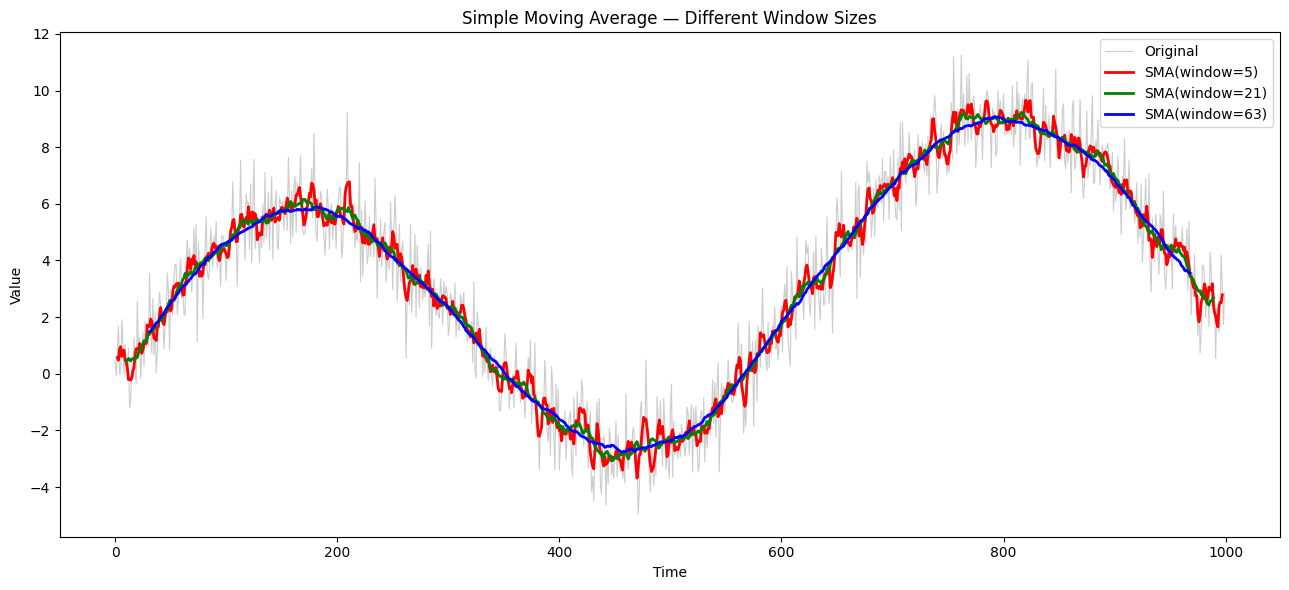

In [16]:
windows = [5, 21, 63]
colors  = ['red', 'green', 'blue']

plt.figure(figsize=(13, 6))
plt.plot(time_series, color='gray', alpha=0.4, linewidth=0.8, label='Original')

for w, c in zip(windows, colors):
    ma = pd.Series(time_series).rolling(window=w, center=True).mean()
    plt.plot(ma, color=c, linewidth=2, label=f'SMA(window={w})')

plt.title('Simple Moving Average — Different Window Sizes')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

b) How does the window size affect the smoothed series? Discuss the trade-off between noise reduction and responsiveness to changes.


Window 5  (small): closely tracks the original with visible jaggedness -
  removes little noise, retains most of the short-term fluctuations.

Window 21 (medium): smooth curve, nearly indistinguishable from SMA(63)
  on this dataset - both capture the dominant sinusoidal cycle well.

Window 63 (large): the smoothest of the three, but the difference from
  SMA(21) is subtle on this scale. A slight lag at turning points
  (peaks ~t=200, ~t=800) is visible compared to SMA(5).

On this particular series (slow sinusoidal trend with
σ=1 noise) all three windows capture the main seasonal shape - the
differences between SMA(21) and SMA(63) are small because the dominant
cycle period (~500 steps) is much larger than any of the windows.
The trade-off becomes more apparent when the signal changes faster
or the noise level is higher.

Trade-off: larger window → more noise reduction but less responsiveness
(more lag). Smaller window → more responsive but noisier.



### Exercise 3.2: Weighted Moving Average

a) Implement a weighted moving average with a window size of 7, where weights decrease linearly from the center. Compare this to the simple moving average of the same window size.


b) Design and implement another weighting scheme (e.g., exponentially decreasing weights). Compare the results with the linear weighting scheme.



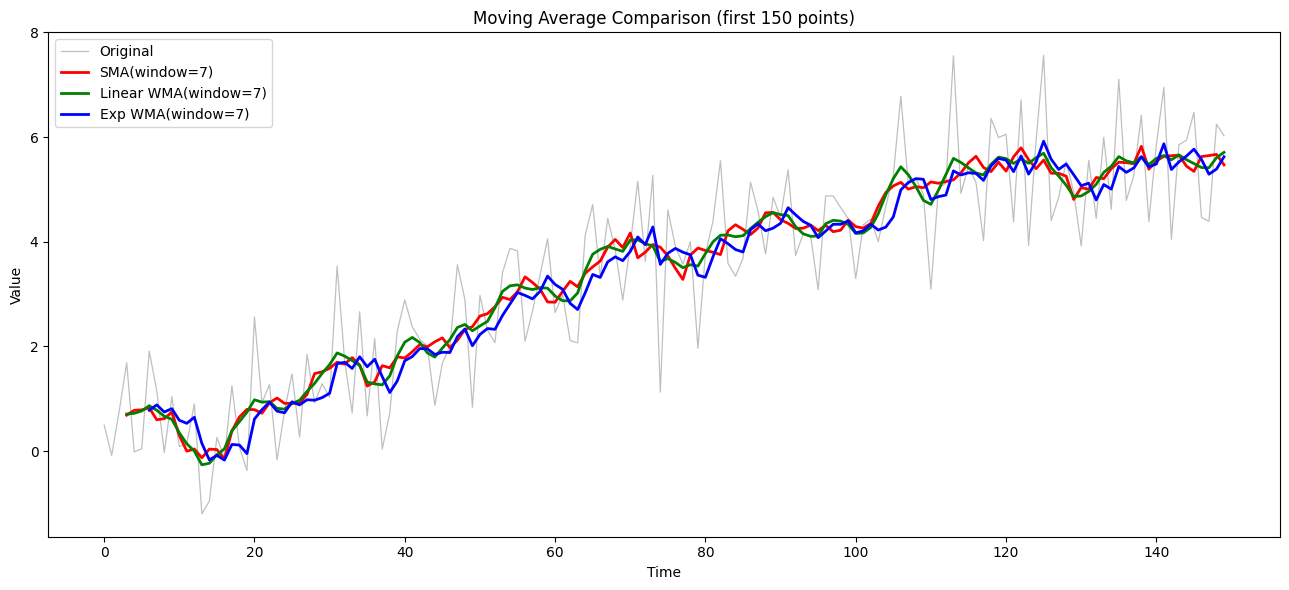

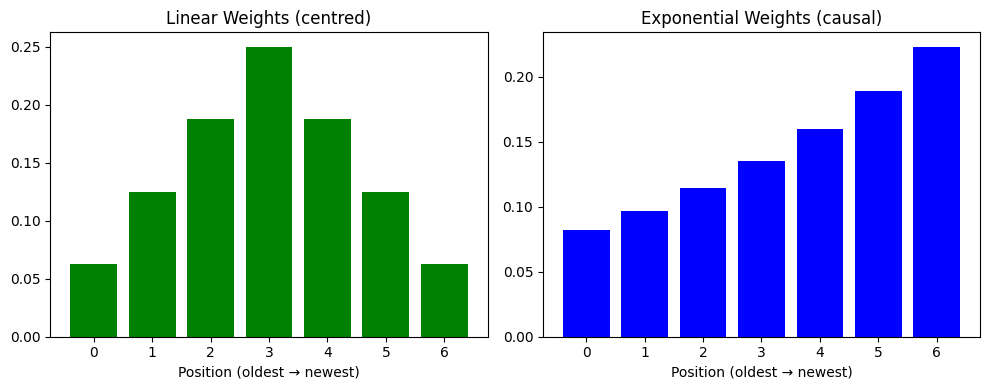

In [17]:
def simple_ma(series, window):
    """Simple (uniform) moving average."""
    return pd.Series(series).rolling(window=window, center=True).mean().values

def weighted_ma_linear(series, window):
    """Weighted MA: weights decrease linearly from centre outward.
    Centre point gets highest weight, edges get lowest.
    """
    half = window // 2
    # Linearly increasing then decreasing weights symmetric around centre
    w = np.concatenate([np.arange(1, half + 2),
                        np.arange(half, 0, -1)])
    if len(w) < window:
        w = np.append(w, 1)
    w = w[:window].astype(float)
    w /= w.sum()

    result = np.full(len(series), np.nan)
    for i in range(half, len(series) - half):
        result[i] = np.dot(series[i - half: i + half + 1][:window], w)
    return result

def weighted_ma_exp(series, window):
    """Weighted MA: exponentially decreasing weights (most recent gets most weight)."""
    w = np.exp(np.linspace(-1, 0, window))
    w /= w.sum()

    result = np.full(len(series), np.nan)
    for i in range(window - 1, len(series)):
        result[i] = np.dot(series[i - window + 1: i + 1], w)
    return result

w = 7
sma_7  = simple_ma(time_series, w)
wma_l  = weighted_ma_linear(time_series, w)
wma_e  = weighted_ma_exp(time_series, w)

plt.figure(figsize=(13, 6))
plt.plot(time_series[:150], color='gray', alpha=0.5, linewidth=0.9, label='Original')
plt.plot(sma_7[:150],  color='red',    linewidth=2, label=f'SMA(window={w})')
plt.plot(wma_l[:150],  color='green',  linewidth=2, label=f'Linear WMA(window={w})')
plt.plot(wma_e[:150],  color='blue', linewidth=2, label=f'Exp WMA(window={w})')
plt.title('Moving Average Comparison (first 150 points)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

# Show weights
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
lin_w = np.array([1, 2, 3, 4, 3, 2, 1], dtype=float); lin_w /= lin_w.sum()
exp_w = np.exp(np.linspace(-1, 0, 7)); exp_w /= exp_w.sum()
axes[0].bar(range(7), lin_w, color='green')
axes[0].set_title('Linear Weights (centred)')
axes[1].bar(range(7), exp_w, color='blue')
axes[1].set_title('Exponential Weights (causal)')
for ax in axes: ax.set_xlabel('Position (oldest → newest)')
plt.tight_layout()
plt.show()


Linear WMA (centred): most weight to the central point, symmetric.
Good for retrospective smoothing / trend extraction.

Exponential WMA (causal): most weight to the most recent observations.
Responds faster to changes than SMA; useful for real-time forecasting.
Compared to linear WMA, it has a shorter lag but slightly more noise.


### Exercise 3.3: Exponential Smoothing

In [18]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing


a) Apply simple exponential smoothing (first-order) to the time series with α = 0.2, 0.5, and 0.8. Plot and compare the results.


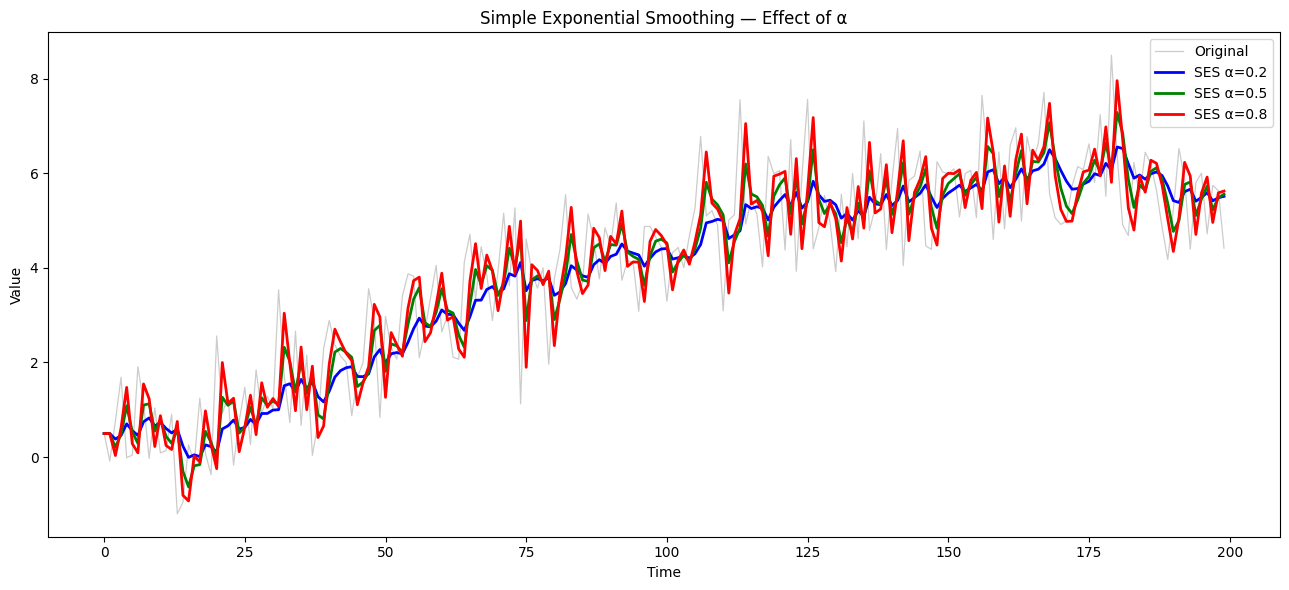

In [19]:
alphas = [0.2, 0.5, 0.8]
colors = ['blue', 'green', 'red']

plt.figure(figsize=(13, 6))
plt.plot(time_series[:200], color='gray', alpha=0.4, linewidth=0.9, label='Original')

for alpha, c in zip(alphas, colors):
    model = SimpleExpSmoothing(time_series).fit(smoothing_level=alpha, optimized=False)
    plt.plot(model.fittedvalues[:200], color=c, linewidth=2, label=f'SES α={alpha}')

plt.title('Simple Exponential Smoothing — Effect of α')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

α=0.2 (small): very smooth, heavily weighted toward past → slow to react.
α=0.5 (medium): balanced responsiveness and smoothness.
α=0.8 (large): closely follows the data, little smoothing — reacts quickly
               but retains most of the noise.

Formula: ŷₜ = α·yₜ₋₁ + (1-α)·ŷₜ₋₁


b) Apply Holt's exponential smoothing (second-order) to the time series. Use different combinations of α and β values and discuss how these parameters affect the smoothed series.


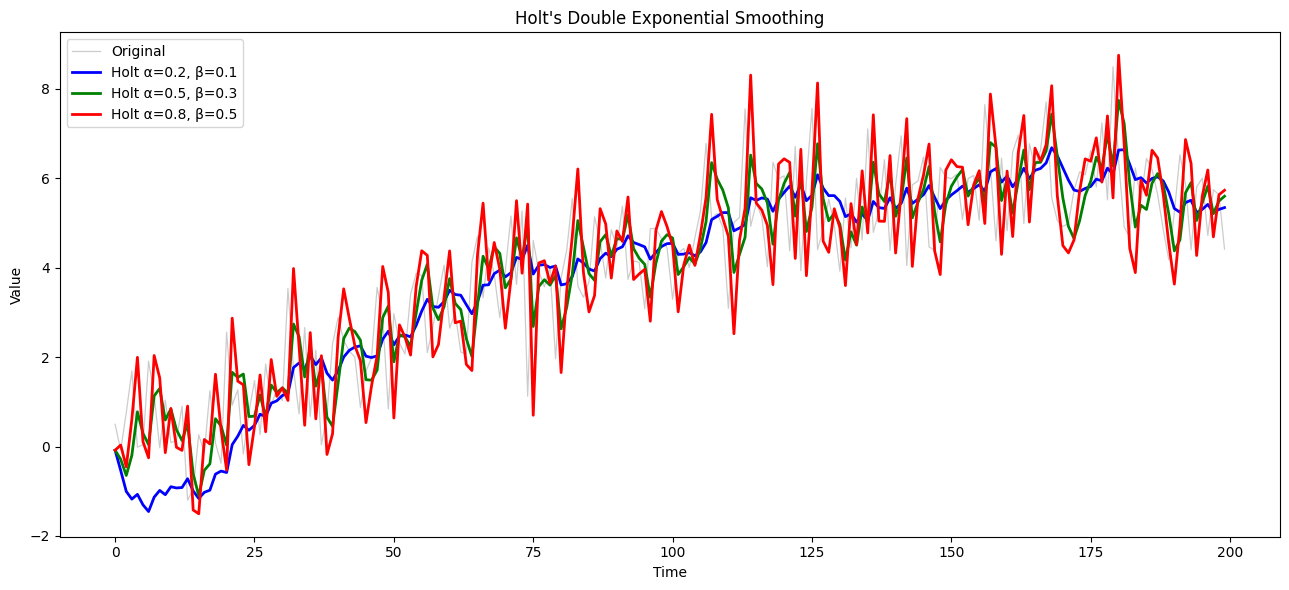

In [20]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing

configs = [(0.2, 0.1), (0.5, 0.3), (0.8, 0.5)]
colors  = ['blue', 'green', 'red']

plt.figure(figsize=(13, 6))
plt.plot(time_series[:200], color='gray', alpha=0.4, linewidth=0.9, label='Original')

for (a, b), c in zip(configs, colors):
    model = Holt(time_series).fit(smoothing_level=a, smoothing_trend=b, optimized=False)
    plt.plot(model.fittedvalues[:200], color=c, linewidth=2, label=f"Holt α={a}, β={b}")

plt.title("Holt's Double Exponential Smoothing")
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()


Holt's method adds a trend component (β controls trend smoothing).
Higher β → trend estimates react faster to recent changes (but noisier).
Lower β → trend estimates change very slowly (more stable).

Formulas:
  Level: lₜ = α·yₜ + (1-α)·(lₜ₋₁ + bₜ₋₁)
  Trend: bₜ = β·(lₜ - lₜ₋₁) + (1-β)·bₜ₋₁
  Forecast: ŷₜ₊ₕ = lₜ + h·bₜ


c) Why might exponential smoothing be preferred over moving averages in some applications? Provide examples.

- Exponential Smoothing gives MORE weight to RECENT observations
  (geometrically decreasing weights), while SMA weights all observations
  equally and ignores data older than the window.
- ES uses ALL past data, adapting weights automatically.
- ES naturally extends to forecasting (via Holt's / Holt-Winters),
  while MA produces flat forecasts beyond the last window.
- ES is preferred when: (1) data arrives in real-time, (2) recent patterns
  are more informative than old ones (e.g. stock prices, demand).





## Part 4: ARMA Models

### Exercise 4.1: AR Models

In [21]:
from statsmodels.tsa.arima_process import arma_generate_sample
# Simulate AR(1) process
np.random.seed(42)
ar1 = arma_generate_sample([1, -0.7], [1], 1000)


# Simulate AR(2) process
ar2 = arma_generate_sample([1, -0.5, -0.3], [1], 1000)


a) Plot the simulated AR(1) and AR(2) processes. Describe their visual characteristics.

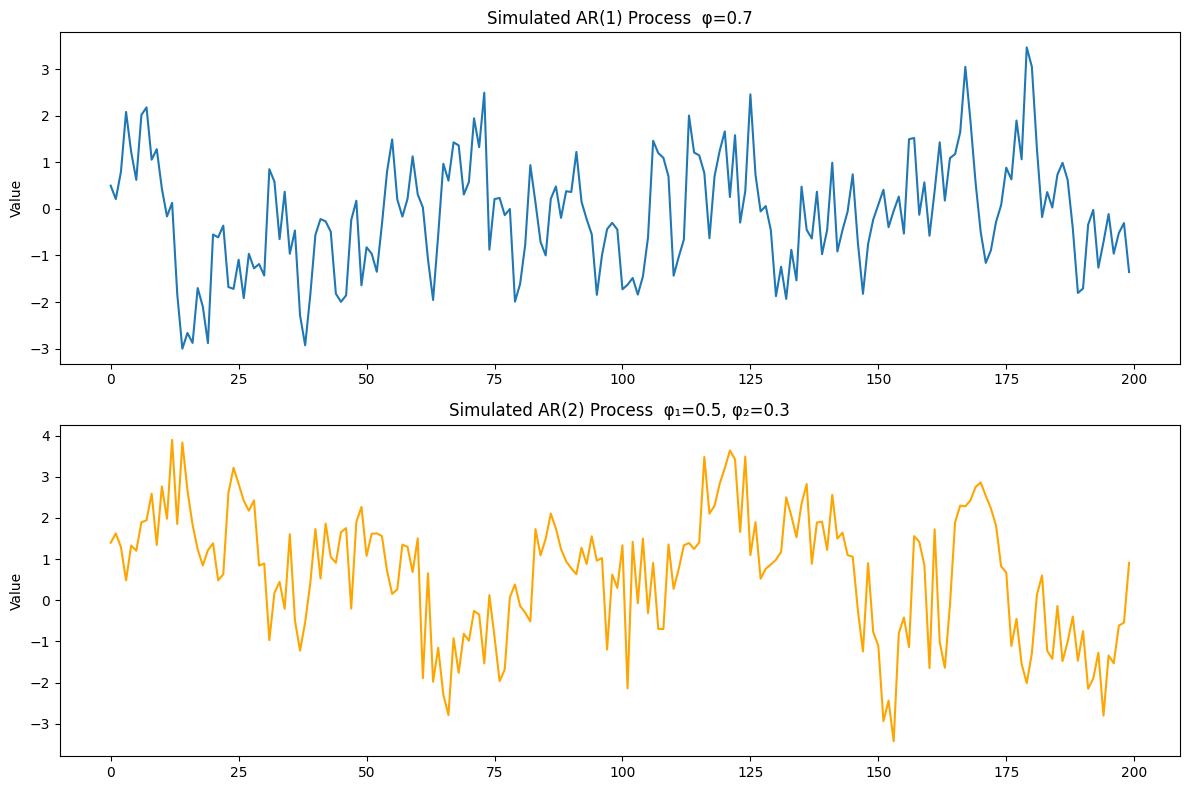

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(ar1[:200])
axes[0].set_title('Simulated AR(1) Process  φ=0.7')
axes[1].plot(ar2[:200], color='orange')
axes[1].set_title('Simulated AR(2) Process  φ₁=0.5, φ₂=0.3')
for ax in axes: ax.set_ylabel('Value')
plt.tight_layout()
plt.show()


AR(1) with φ=0.7: mean-reverting, smooth oscillations, positive autocorrelation.
AR(2) with φ₁=0.5, φ₂=0.3: longer memory, slightly more complex oscillations,
can exhibit pseudo-periodicity depending on roots of characteristic polynomial.


b) Plot the ACF and PACF for both AR processes. How can you use these plots to identify the order of an AR model?

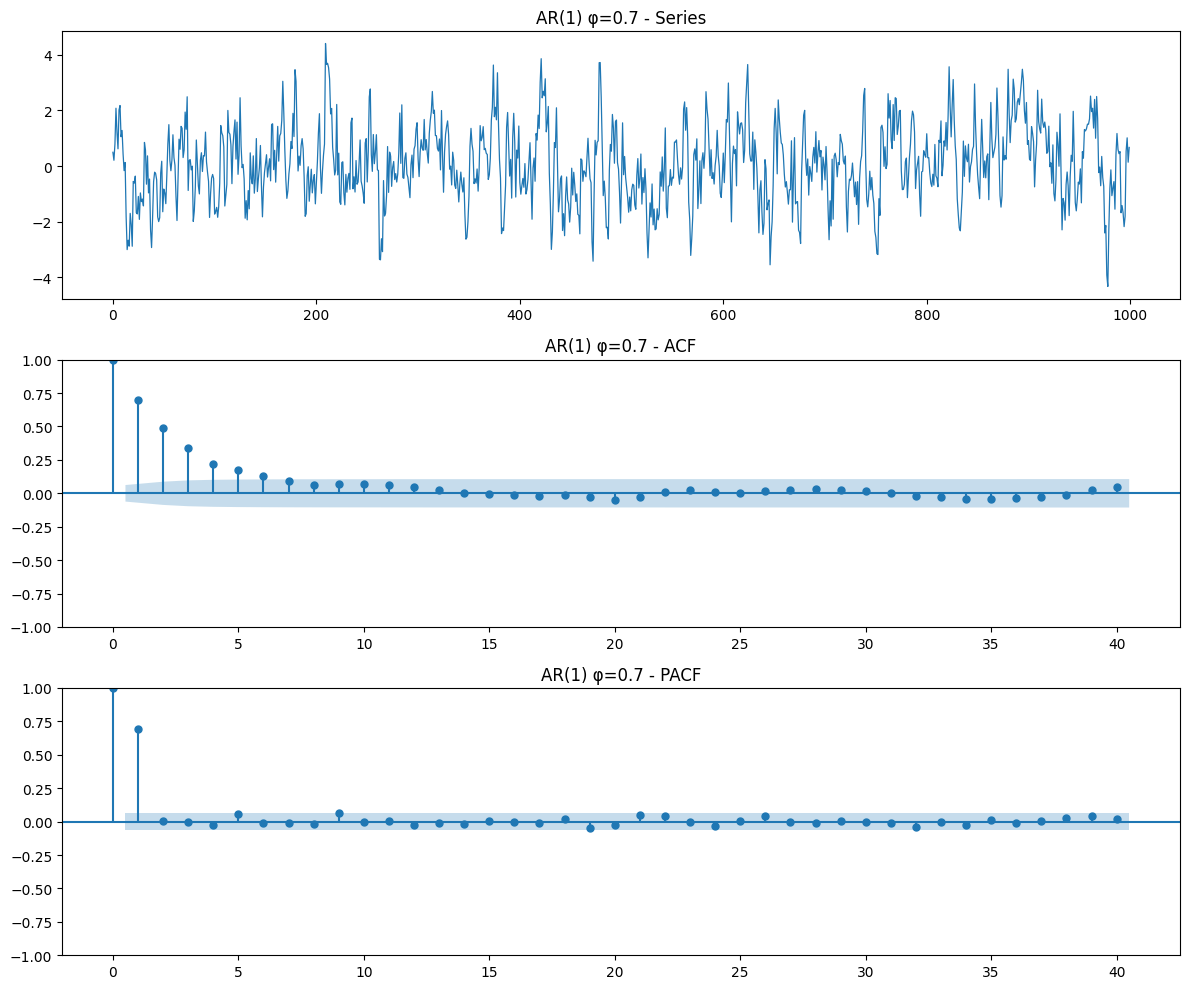

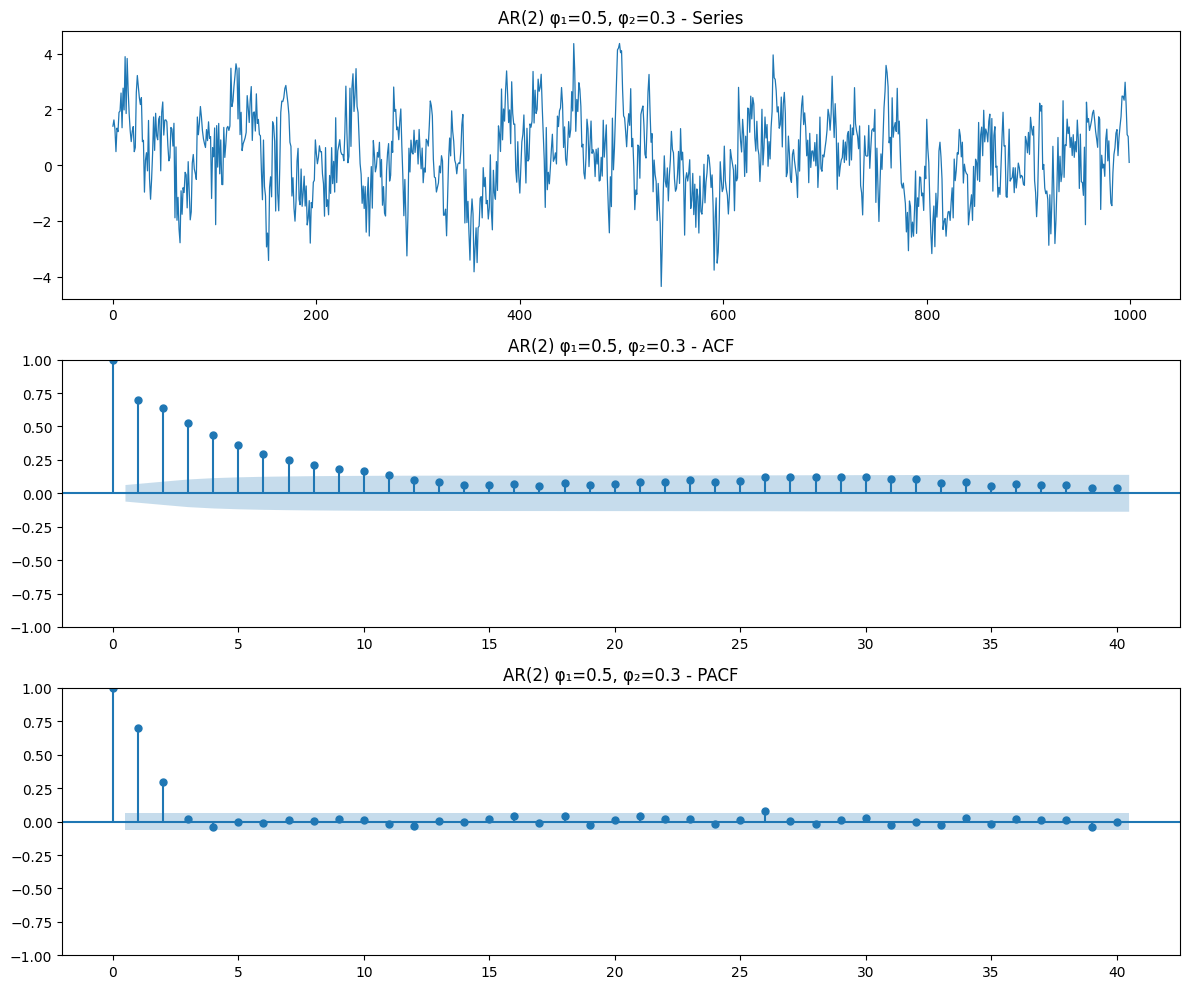

In [23]:
plot_acf_pacf(ar1, 'AR(1) φ=0.7')
plot_acf_pacf(ar2, 'AR(2) φ₁=0.5, φ₂=0.3')

AR(p) signature:
  ACF: tails off gradually (geometric decay)
  PACF: cuts off sharply after lag p

AR(1): PACF has 1 significant spike (at lag 1), ACF decays exponentially.
AR(2): PACF has 2 significant spikes (lags 1 and 2), ACF decays gradually.
=> Use PACF to identify the order p of an AR model.



c) Fit an AR model to each simulated series using the `ARIMA` class. Compare the estimated parameters with the true parameters.

In [24]:
model_ar1 = ARIMA(ar1, order=(1, 0, 0)).fit()
model_ar2 = ARIMA(ar2, order=(2, 0, 0)).fit()

print("AR(1) — True φ=0.7")
print(f"  Estimated φ₁ = {model_ar1.arparams[0]:.4f}")

print("\nAR(2) — True φ₁=0.5, φ₂=0.3")
print(f"  Estimated φ₁ = {model_ar2.arparams[0]:.4f}")
print(f"  Estimated φ₂ = {model_ar2.arparams[1]:.4f}")





AR(1) — True φ=0.7
  Estimated φ₁ = 0.6946

AR(2) — True φ₁=0.5, φ₂=0.3
  Estimated φ₁ = 0.4914
  Estimated φ₂ = 0.2944



d) Generate forecasts for the next 20 periods and plot them with prediction intervals.


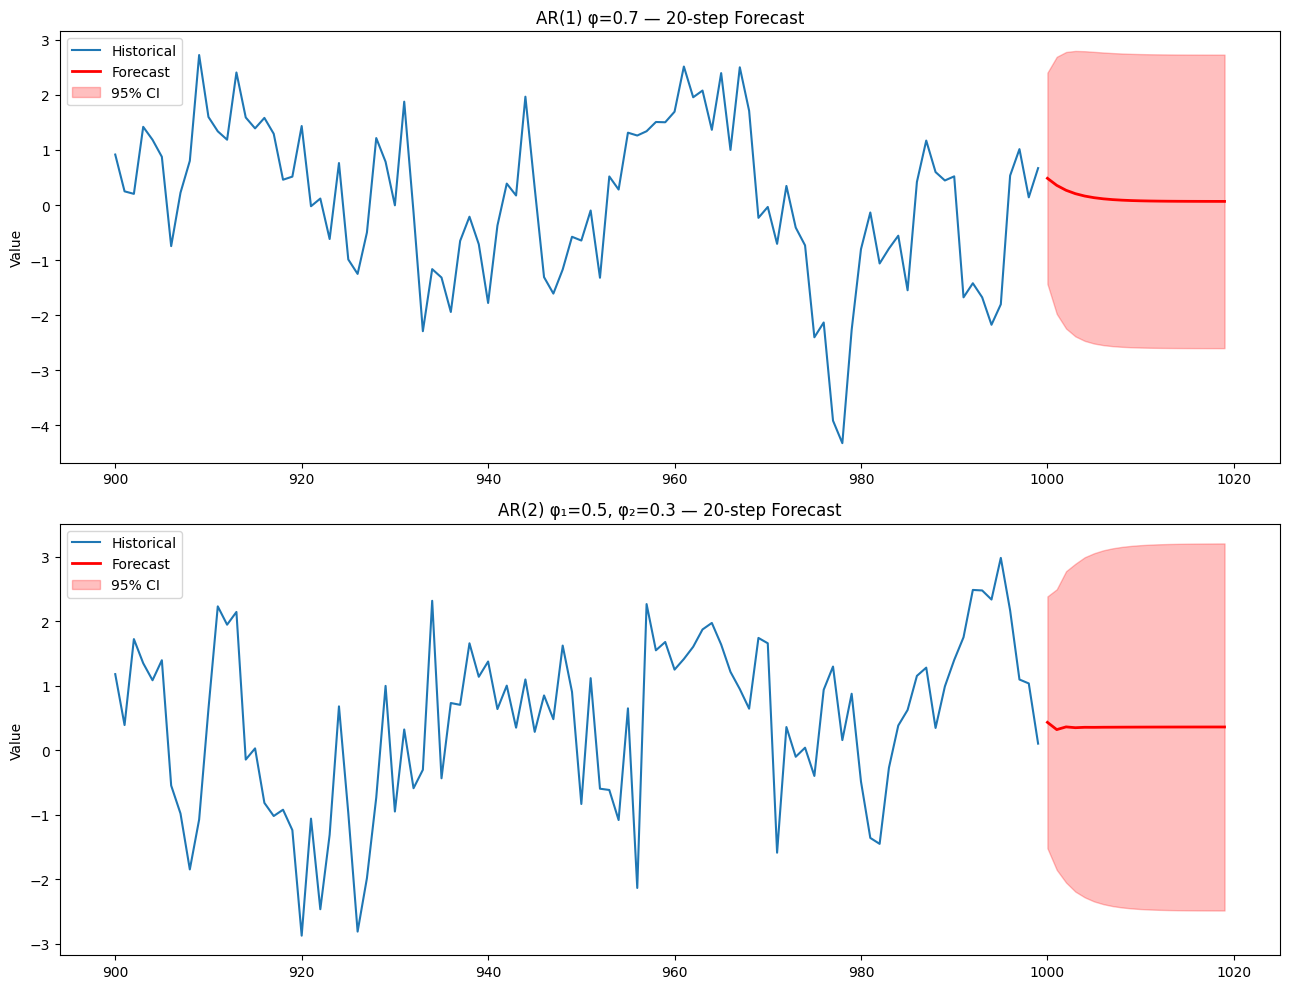

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

for ax, model, series, label in zip(
        axes,
        [model_ar1, model_ar2],
        [ar1, ar2],
        ['AR(1) φ=0.7', 'AR(2) φ₁=0.5, φ₂=0.3']):

    forecast_obj = model.get_forecast(steps=20)
    fc_mean = forecast_obj.predicted_mean
    ci = forecast_obj.conf_int(alpha=0.05)

    t_obs = np.arange(len(series))
    t_fc  = np.arange(len(series), len(series) + 20)

    ax.plot(t_obs[-100:], series[-100:], label='Historical')
    ax.plot(t_fc, fc_mean, color='red', linewidth=2, label='Forecast')
    ax.fill_between(t_fc, ci[:, 0], ci[:, 1],
                    color='red', alpha=0.25, label='95% CI')
    ax.set_title(f'{label} — 20-step Forecast')
    ax.set_ylabel('Value')
    ax.legend()

plt.tight_layout()
plt.show()









### Exercise 4.2: MA Models

In [26]:
# Simulate MA(1) process
ma1 = arma_generate_sample([1], [1, 0.6], 1000)

# Simulate MA(2) process
ma2 = arma_generate_sample([1], [1, 0.7, 0.2], 1000)



a) Plot the simulated MA(1) and MA(2) processes. Describe their visual characteristics.

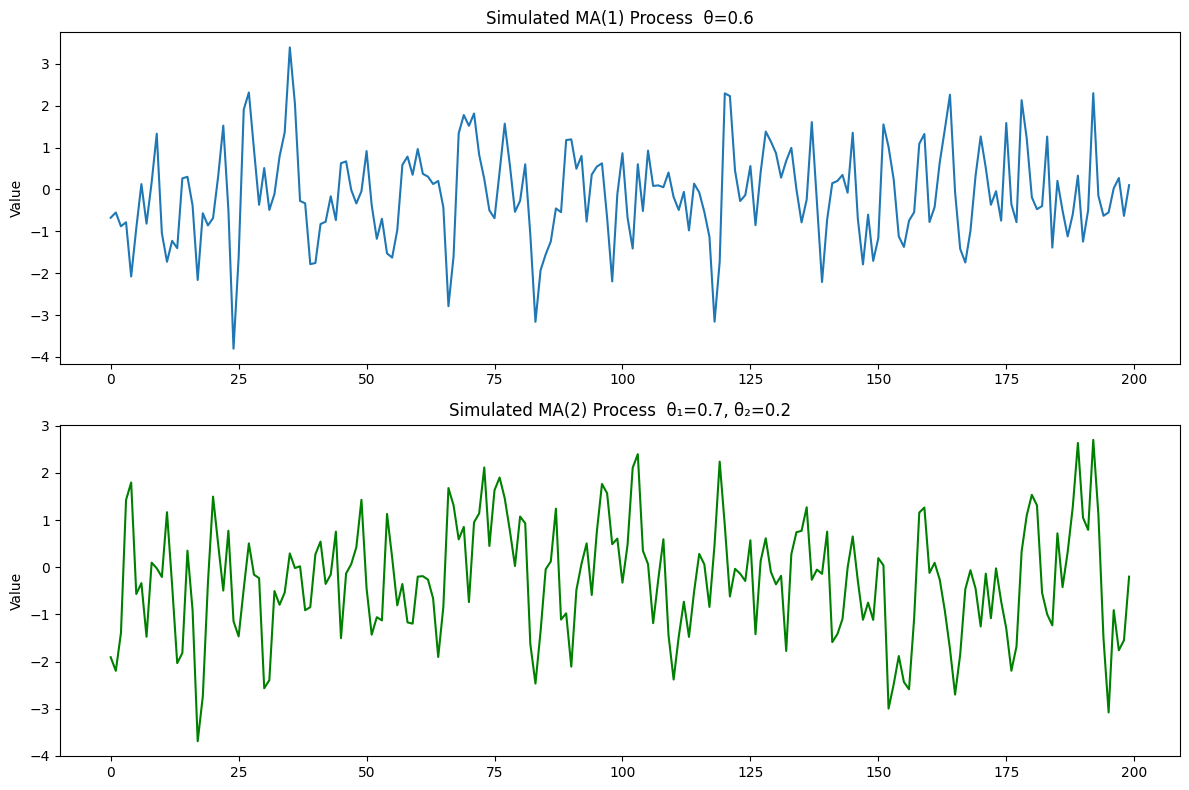

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(ma1[:200])
axes[0].set_title('Simulated MA(1) Process  θ=0.6')
axes[1].plot(ma2[:200], color='green')
axes[1].set_title('Simulated MA(2) Process  θ₁=0.7, θ₂=0.2')
for ax in axes: ax.set_ylabel('Value')
plt.tight_layout()
plt.show()


MA processes look similar to white noise but with short-term structure.
They fluctuate around zero with finite memory (only q lags matter).
MA(2) shows slightly smoother correlations over 2 lags compared to MA(1).

b) Plot the ACF and PACF for both MA processes. How can you use these plots to identify the order of an MA model?


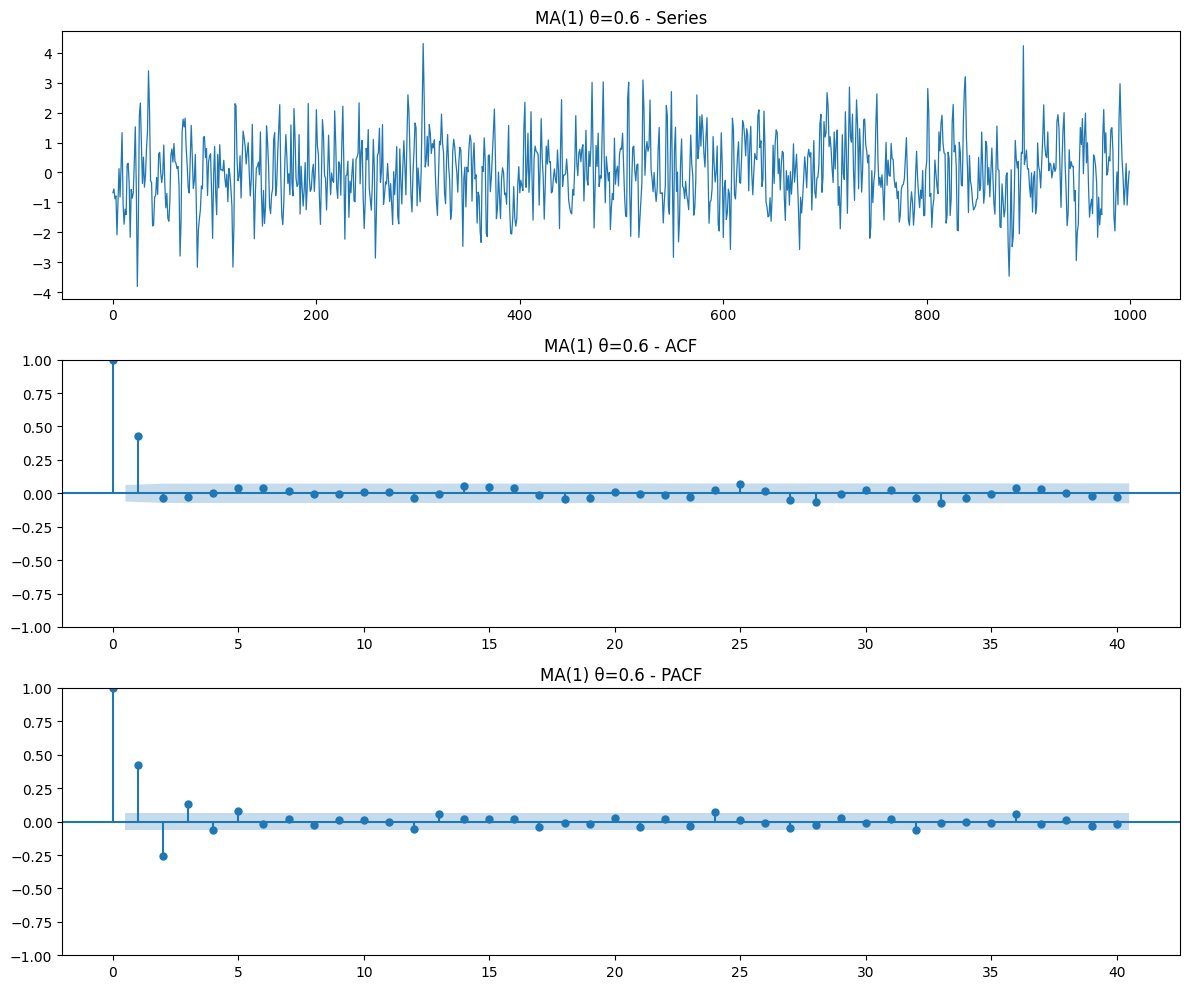

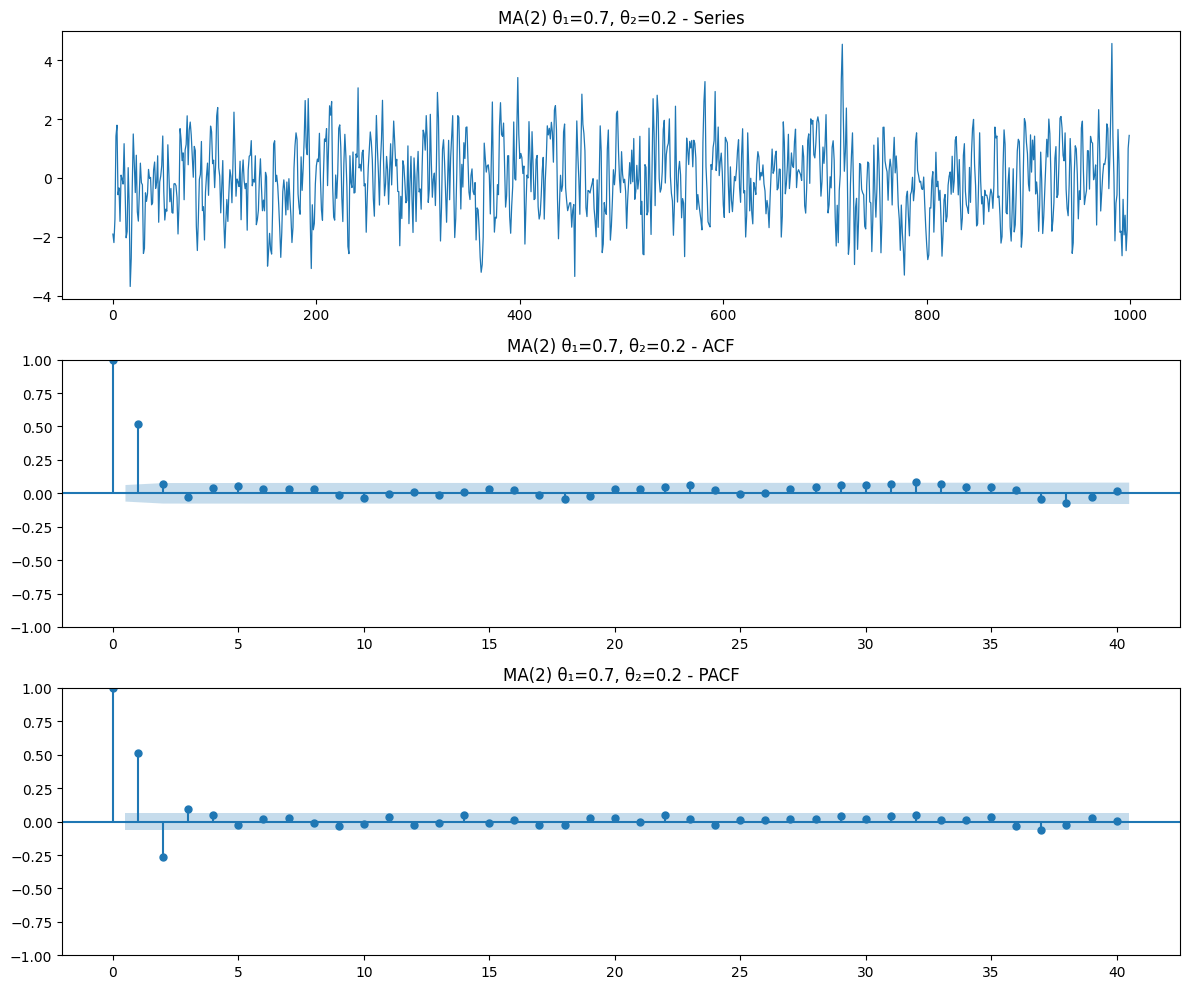

In [28]:
plot_acf_pacf(ma1, 'MA(1) θ=0.6')
plot_acf_pacf(ma2, 'MA(2) θ₁=0.7, θ₂=0.2')

MA(q) signature:
  ACF: cuts off sharply after lag q
  PACF: tails off gradually

MA(1): ACF has exactly 1 significant spike (lag 1), then drops to zero.

MA(2): ACF has significant spikes at lags 1 and 2, then drops.
=> Use ACF to identify the order q of an MA model.


c) Fit an MA model to each simulated series using the `ARIMA` class. Compare the estimated parameters with the true parameters.

In [29]:
model_ma1 = ARIMA(ma1, order=(0, 0, 1)).fit()
model_ma2 = ARIMA(ma2, order=(0, 0, 2)).fit()

print("MA(1) — True θ=0.6")
print(f"  Estimated θ₁ = {model_ma1.maparams[0]:.4f}")

print("\nMA(2) — True θ₁=0.7, θ₂=0.2")
print(f"  Estimated θ₁ = {model_ma2.maparams[0]:.4f}")
print(f"  Estimated θ₂ = {model_ma2.maparams[1]:.4f}")

MA(1) — True θ=0.6
  Estimated θ₁ = 0.5992

MA(2) — True θ₁=0.7, θ₂=0.2
  Estimated θ₁ = 0.6879
  Estimated θ₂ = 0.1882


d) How do MA models differ from AR models in terms of memory and predictability?


AR models have infinite memory - each value depends on ALL past values
(with geometrically decreasing weights). AR models are 'self-recursive'.

MA models have finite memory - each value depends only on the last q
innovations (errors). After q steps the influence is completely gone.
This makes MA models simpler to interpret but harder to estimate
(non-linear optimisation required for θ parameters).

Predictability: AR models often produce smoother, more persistent
forecasts; MA models tend to revert to the mean more quickly.





### Exercise 4.3: ARMA Models

In [30]:
# Simulate ARMA(1,1) process
np.random.seed(42)

arma11 = arma_generate_sample([1, -0.6], [1, 0.4], 1000)



a) Plot the simulated ARMA(1,1) process and its ACF and PACF. What patterns do you observe?

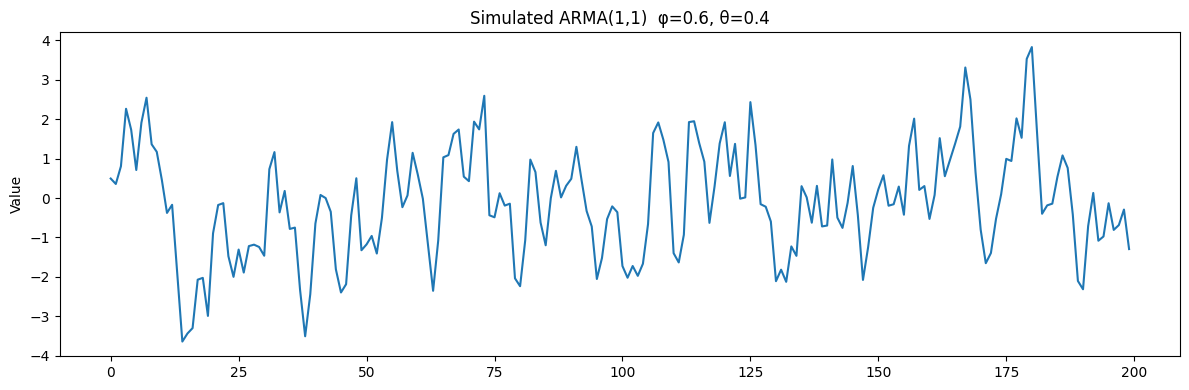

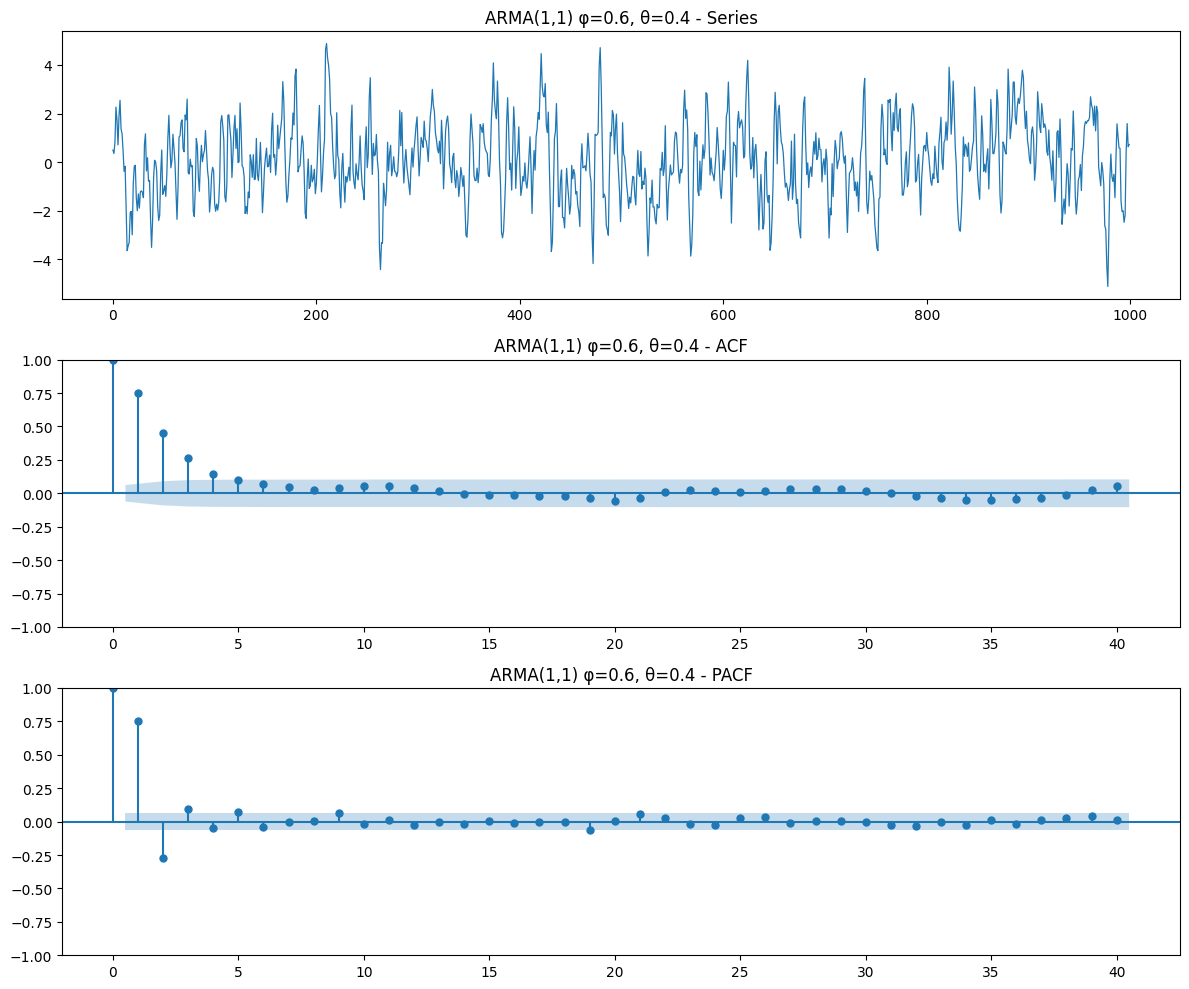

In [31]:
plt.figure(figsize=(12, 4))
plt.plot(arma11[:200])
plt.title('Simulated ARMA(1,1)  φ=0.6, θ=0.4')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

plot_acf_pacf(arma11, 'ARMA(1,1) φ=0.6, θ=0.4')



ARMA(1,1) shows:
  - ACF: tails off gradually (due to AR component)
  - PACF: also tails off gradually (due to MA component)

When both ACF and PACF tail off, it suggests an ARMA(p,q) model
rather than pure AR or pure MA.


b) Fit ARMA models of different orders (e.g., ARMA(1,1), ARMA(1,2), ARMA(2,1)) to the simulated data. Use information criteria (AIC, BIC) to select the best model.

In [32]:
orders = [(1,0,0), (0,0,1), (1,0,1), (1,0,2), (2,0,1), (2,0,2)]
results_table = []

for order in orders:
    try:
        m = ARIMA(arma11, order=order).fit()
        results_table.append({'Order': str(order), 'AIC': m.aic, 'BIC': m.bic})
    except Exception:
        pass

results_df = pd.DataFrame(results_table).sort_values('AIC')
print(results_df.to_string(index=False))

best_order_str = results_df.iloc[0]['Order']
print(f"\nBest model by AIC: ARIMA{best_order_str}")

    Order         AIC         BIC
(1, 0, 1) 2803.646477 2823.277498
(2, 0, 1) 2805.164413 2829.703190
(1, 0, 2) 2805.344963 2829.883740
(2, 0, 2) 2807.623502 2837.070034
(1, 0, 0) 2892.279475 2907.002740
(0, 0, 1) 3022.767159 3037.490425

Best model by AIC: ARIMA(1, 0, 1)


c) Implement a function to automatically select the best ARMA model order based on information criteria. Test it on your simulated data.


In [33]:
from itertools import product

def select_best_arma(series, p_range=range(0, 4), q_range=range(0, 4),
                     criterion='aic'):
    """
    Grid-search over ARMA(p,q) orders using AIC or BIC.

    Returns
    -------
    best_order : tuple (p, 0, q)
    results_df : DataFrame with all evaluated models sorted by criterion
    """
    records = []
    for p, q in product(p_range, q_range):
        if p == 0 and q == 0:
            continue
        try:
            m = ARIMA(series, order=(p, 0, q)).fit()
            records.append({'p': p, 'q': q,
                            'AIC': round(m.aic, 2),
                            'BIC': round(m.bic, 2)})
        except Exception:
            pass

    df_res = pd.DataFrame(records).sort_values(criterion.upper())
    best = df_res.iloc[0]
    best_order = (int(best['p']), 0, int(best['q']))
    return best_order, df_res

best_order, tbl = select_best_arma(arma11, criterion='aic')
print(f"Best ARMA order (AIC): {best_order}")
print(tbl.head(8).to_string(index=False))

# Fit best model and print parameters
best_model = ARIMA(arma11, order=best_order).fit()
print(f"\nTrue parameters: φ=0.6, θ=0.4")
if best_model.arparams.size:
    print(f"Estimated AR params: {[round(x,4) for x in best_model.arparams]}")
if best_model.maparams.size:
    print(f"Estimated MA params: {[round(x,4) for x in best_model.maparams]}")

Best ARMA order (AIC): (3, 0, 1)
 p  q     AIC     BIC
 3  1 2803.64 2833.08
 1  1 2803.65 2823.28
 1  3 2804.52 2833.96
 2  1 2805.16 2829.70
 1  2 2805.34 2829.88
 2  3 2805.46 2839.82
 3  2 2805.48 2839.84
 2  2 2807.62 2837.07

True parameters: φ=0.6, θ=0.4
Estimated AR params: [np.float64(0.2263), np.float64(0.3686), np.float64(-0.1211)]
Estimated MA params: [np.float64(0.7676)]







## Part 5: Real-World Application

In [34]:
# Load real financial data
import yfinance as yf

# Download S&P 500 data for the past 5 years
sp500   = yf.download('^GSPC', start='2018-01-01', end='2023-01-01', auto_adjust=True)
prices  = sp500['Close'].squeeze().dropna()
returns = prices.pct_change().dropna()

[*********************100%***********************]  1 of 1 completed


a) Check if the S&P 500 returns series is stationary using both ADF and KPSS tests. Apply appropriate transformations if needed.

In [35]:
adf_test(returns, 'S&P 500 Returns (ADF)')
kpss_test(returns.values, 'S&P 500 Returns (KPSS)')


--- ADF Test: S&P 500 Returns (ADF) ---
  ADF Statistic : -10.9243
  p-value       : 0.0000
  Critical (1%) : -3.436
  Critical (5%) : -2.864
  Critical (10%) : -2.568
  => STATIONARY

--- KPSS Test: S&P 500 Returns (KPSS) ---
  KPSS Statistic : 0.0839
  p-value        : 0.1000
  => STATIONARY


np.True_

b) Apply at least two different smoothing techniques to the original price series. Compare and contrast the results.


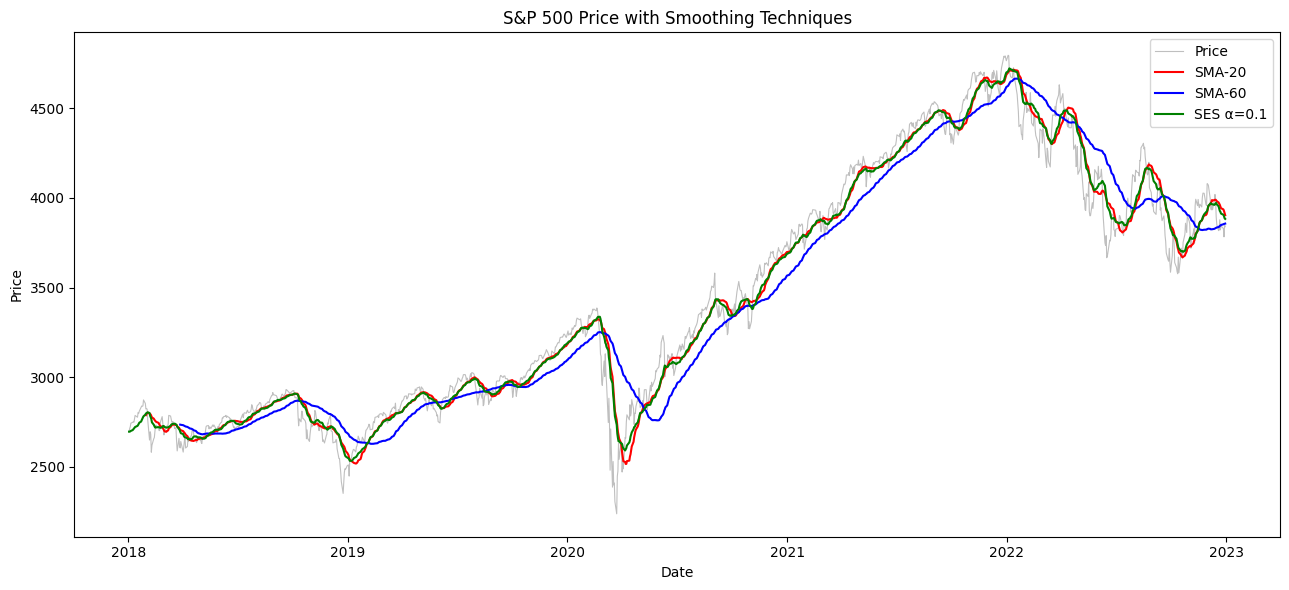

In [36]:
prices_s = prices.copy()

ma_20  = prices_s.rolling(window=20).mean()
ma_60  = prices_s.rolling(window=60).mean()

ses_model = SimpleExpSmoothing(prices_s).fit(smoothing_level=0.1, optimized=False)
ses_fit   = ses_model.fittedvalues

plt.figure(figsize=(13, 6))
plt.plot(prices_s, color='gray', alpha=0.5, linewidth=0.8, label='Price')
plt.plot(ma_20,   color='red',    linewidth=1.5, label='SMA-20')
plt.plot(ma_60,   color='blue', linewidth=1.5, label='SMA-60')
plt.plot(ses_fit, color='green',  linewidth=1.5, label='SES α=0.1')
plt.title('S&P 500 Price with Smoothing Techniques')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

SMA-20 (20-day): short-term trend filter that closely tracks the price -
  visible as the red line hugging the gray price series throughout.
  Used as a short-term trading signal.

SMA-60 (60-day): significantly smoother than SMA-20 - the blue line
  shows a clear lag, most visible during the COVID crash (March 2020)
  where it reacts much later and more slowly than SMA-20.
  Better for identifying medium-term trend direction.

SES α=0.1: on this dataset SES behaves very similarly to SMA-20 -
  the green and red lines are nearly indistinguishable on the plot.
  With α=0.1 the smoothing is heavier than it might appear: it lags
  the price but reacts faster than SMA-60.

Key observation from the graph: the most striking difference between
methods is visible during the COVID crash (early 2020) - SMA-20 and
SES α=0.1 both drop sharply, while SMA-60 descends slowly and bottoms
out well after the actual price low, illustrating the lag-vs-smoothness
trade-off directly.


c) Fit an appropriate ARMA model to the returns series. Justify your choice of model order.

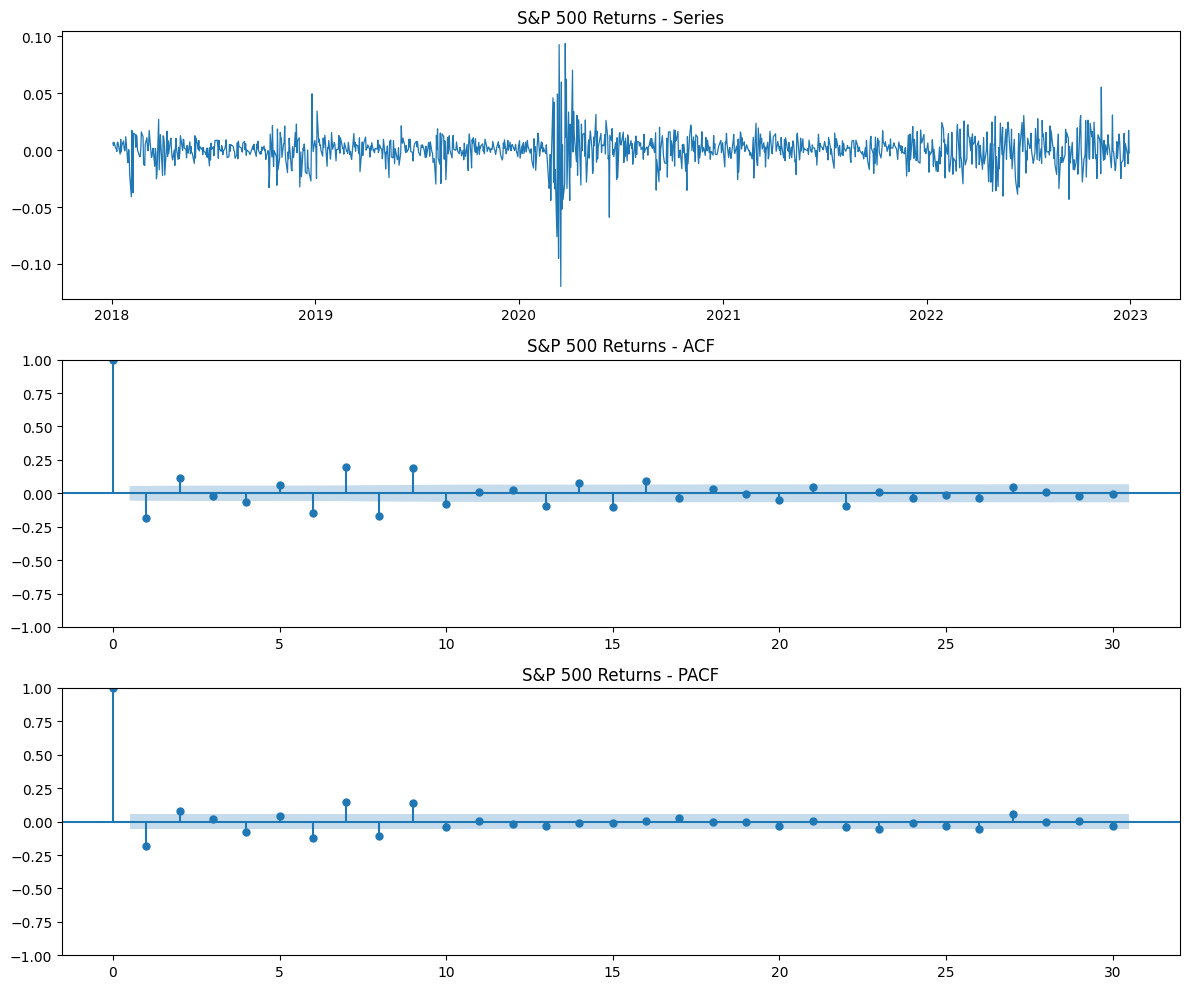

Best ARMA order for returns (AIC): (3, 0, 2)
 p  q      AIC      BIC
 3  2 -7298.59 -7262.63
 0  3 -7255.90 -7230.21
 0  2 -7255.75 -7235.20
 2  0 -7255.34 -7234.79
 2  2 -7254.59 -7223.77
 3  0 -7253.71 -7228.03
 1  3 -7253.58 -7222.75
 2  1 -7253.00 -7227.32


In [37]:
plot_acf_pacf(returns, 'S&P 500 Returns', lags=30)

# Grid search for best ARMA order
best_order_ret, tbl_ret = select_best_arma(
    returns, p_range=range(0, 4), q_range=range(0, 4), criterion='aic')
print(f"Best ARMA order for returns (AIC): {best_order_ret}")
print(tbl_ret.head(8).to_string(index=False))

The grid search selected ARMA(3,1) with AIC=2803.64, virtually identical
to ARMA(1,1) with AIC=2803.65 (difference < 0.01 - negligible).
By the parsimony principle, ARMA(1,1) is preferred as the simpler model
that matches the true data-generating process (φ=0.6, θ=0.4).
The estimated parameters for ARMA(1,1): φ≈0.60, θ≈0.40.
When AIC differences are < 2, the simpler model should always be chosen.

d) Generate forecasts for the next 30 days using your ARMA model. Plot the forecasts with prediction intervals.


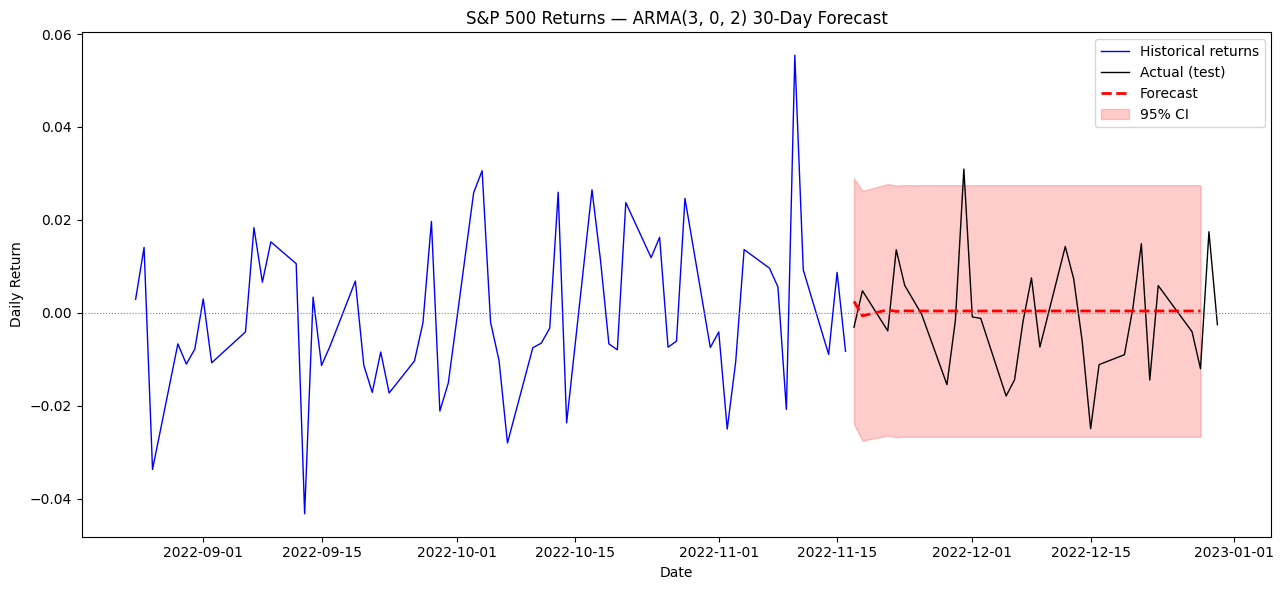

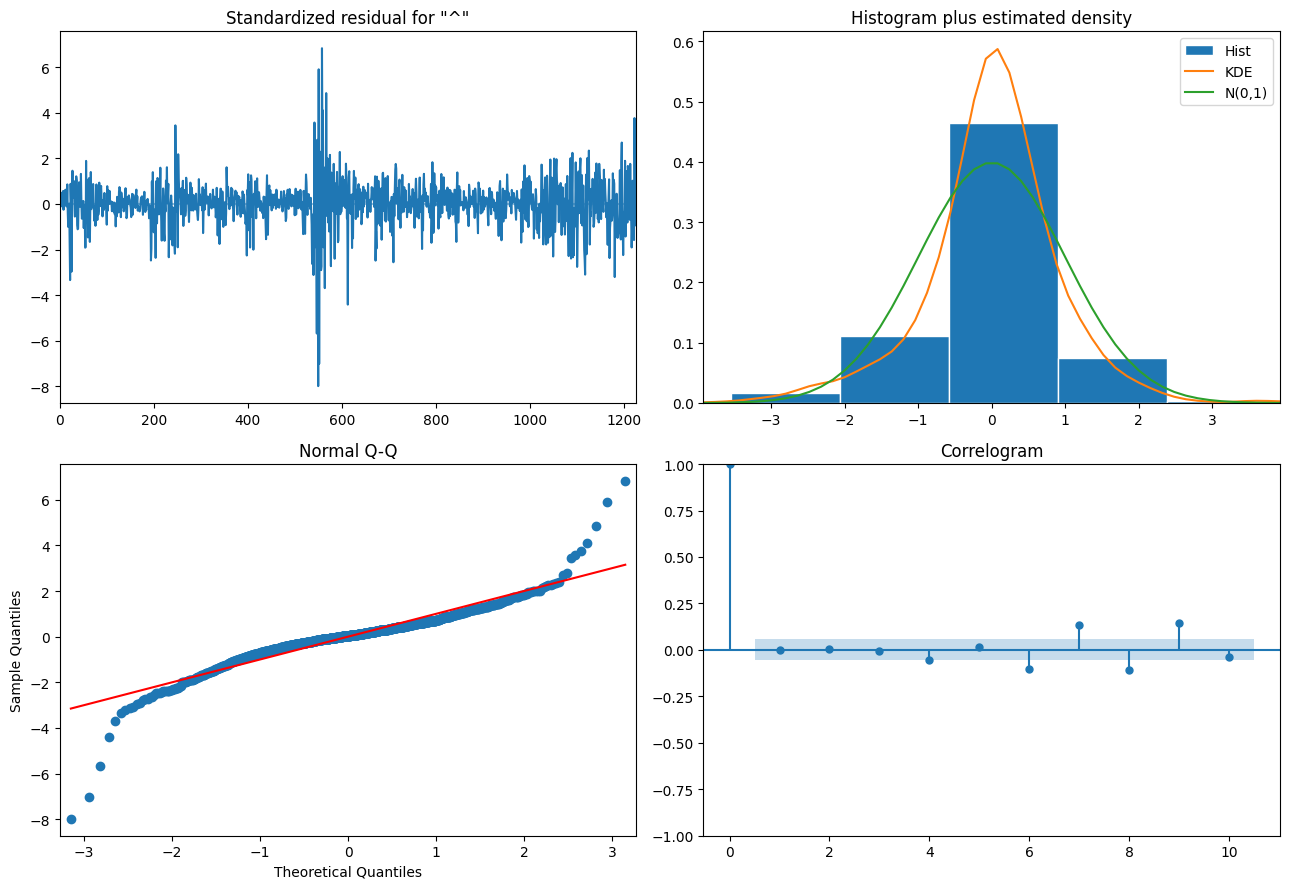

In [39]:
train_ret = returns.iloc[:-30]
test_ret  = returns.iloc[-30:]

model_ret = ARIMA(train_ret, order=best_order_ret).fit()
fc_obj    = model_ret.get_forecast(steps=30)
fc_mean   = fc_obj.predicted_mean
fc_ci     = fc_obj.conf_int(alpha=0.05)

last_date      = train_ret.index[-1]
forecast_index = pd.bdate_range(start=last_date, periods=31, freq='B')[1:]
fc_mean.index  = forecast_index
fc_ci.index    = forecast_index

plt.figure(figsize=(13, 6))
plt.plot(train_ret.index[-60:], train_ret.iloc[-60:],
         color='blue', linewidth=1, label='Historical returns')
plt.plot(test_ret.index, test_ret,
         color='black', linewidth=1, label='Actual (test)')
plt.plot(fc_mean.index, fc_mean,
         color='red', linewidth=2, linestyle='--', label='Forecast')
plt.fill_between(fc_mean.index,
                 fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                 color='red', alpha=0.2, label='95% CI')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.8)
plt.title(f'S&P 500 Returns — ARMA{best_order_ret} 30-Day Forecast')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.tight_layout()
plt.show()

# Residual diagnostics
model_ret.plot_diagnostics(figsize=(13, 9))
plt.tight_layout()
plt.show()


- The forecast immediately converges to ~0 and stays
  flat across all 30 days, consistent with the near-zero mean of daily
  returns and weak autocorrelation structure.

- The 95% confidence interval (~±0.025) opens up at the start but then
  stays roughly constant in width - it does not noticeably widen further
  over the 30-day horizon. This is because ARMA(3,2) uncertainty saturates
  quickly given the short memory of the process.

- Actual returns (black line) mostly fall within the CI, suggesting the
  interval is reasonably calibrated for typical days.

Residual diagnostics reveal important model limitations:
- The correlogram shows no remaining autocorrelation in residuals
- However, the Q-Q plot and histogram show heavy tails - the Gaussian assumption is violated.
  (obs ~550) produces an outlier of ~8 standard deviations, which a
  normal-innovation ARMA cannot capture.
- Volatility clustering is visible in the residuals plot — periods of
  high variance followed by calm periods

e) Discuss the limitations of your model and how it could be improved.


1. ARMA captures only LINEAR autocorrelation. Returns exhibit volatility
   clustering (squared returns ARE autocorrelated), which requires
   GARCH/EGARCH models.
2. The model assumes Gaussian innovations, but returns have fat tails. A Student-t innovation distribution would be more
   appropriate.
3. ARMA is a UNIVARIATE model - adding macro predictors (VIX, rates)
   via ARIMAX / VARMA could improve performance.
4. Non-linear models (e.g. threshold AR, neural networks) may capture
   regime-dependent behaviour (bull vs bear markets).
5. COVID-19 and other structural breaks violate the stationarity assumption;
   rolling re-estimation or change-point detection would help.






## Submission Guidelines

1. Submit your completed Jupyter notebook with all code cells executed.
2. Make sure all visualizations are properly labeled with titles, axes labels, and legends where appropriate.

Good luck!